# QQQ 200 SMA Breakout Strategy (Long-Only)

**Strategy Overview:**
- Entry: Go long when Close crosses above 200-day SMA (breakthrough from below)
- Stop Loss: Fixed 3% below entry price (simple fixed stop, no trailing)
- Exit: Either position held > 8 weeks (≈40 trading days), OR a strong bearish candlestick pattern appears
- Bearish Exit Signals: CDLEVENINGSTAR, CDLDARKCLOUDCOVER, CDLHANGINGMAN, CDLSHOOTINGSTAR, CDLENGULFING < 0, CDLHARAMI < 0
- No overlapping positions — only one long at a time
- Backtest on full historical QQQ data (from earliest available to current)

**Ticker:** QQQ (Invesco QQQ Trust ETF)

In [126]:
# Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib  # TA-Lib for candlestick patterns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [127]:
# Data Download - Multiple Tickers
tickers = ['TSLA', 'MSFT', 'AAPL']

print(f"Downloading data for {tickers}...")

# Download data for all tickers
data_dict = {}
for ticker in tickers:
    print(f"\nDownloading {ticker}...")
    data_raw = yf.download(ticker, start='1999-01-01', progress=False, auto_adjust=True)
    
    # Handle MultiIndex columns (yfinance returns MultiIndex for single ticker)
    if isinstance(data_raw.columns, pd.MultiIndex):
        # Flatten MultiIndex columns
        data_raw.columns = data_raw.columns.get_level_values(0)
    
    # Select required columns
    required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    if 'Adj Close' in data_raw.columns:
        required_cols.append('Adj Close')
    
    data = data_raw[required_cols].copy()
    
    # If Adj Close doesn't exist, create it from Close
    if 'Adj Close' not in data.columns:
        data['Adj Close'] = data['Close']
    
    data_dict[ticker] = data
    print(f"  {ticker}: {len(data)} records, Date range: {data.index[0]} to {data.index[-1]}")

# Store first ticker's data as 'data' for backward compatibility
data = data_dict[tickers[0]]

print(f"\n{'='*60}")
print(f"Successfully downloaded data for {len(data_dict)} tickers")
print(f"{'='*60}")


  TSLA: 3933 records, Date range: 2010-06-29 00:00:00 to 2026-02-17 00:00:00

  MSFT: 6822 records, Date range: 1999-01-04 00:00:00 to 2026-02-17 00:00:00

  AAPL: 6822 records, Date range: 1999-01-04 00:00:00 to 2026-02-17 00:00:00

Successfully downloaded data for 3 tickers


In [128]:
# Indicators & Signals

# Calculate 200-day Simple Moving Average
data['SMA200'] = data['Close'].rolling(window=200, min_periods=200).mean()

# Identify when price is above SMA200
data['Above_SMA'] = data['Close'] > data['SMA200']

# Breakout signal: Close crosses above SMA200 (was below yesterday, above today)
data['Breakout'] = (data['Close'] > data['SMA200']) & (data['Close'].shift(1) <= data['SMA200'].shift(1))

print(f"Breakout signals detected: {data['Breakout'].sum()}")

# Strong bearish exit signals (TA-Lib returns negative values for bearish patterns)
# Evening Star: -100 to -1 for bearish
data['CDL_EVENINGSTAR'] = talib.CDLEVENINGSTAR(data['Open'].values, data['High'].values, data['Low'].values, data['Close'].values)

# Dark Cloud Cover: -100 to -1 for bearish
data['CDL_DARKCLOUDCOVER'] = talib.CDLDARKCLOUDCOVER(data['Open'].values, data['High'].values, data['Low'].values, data['Close'].values)

# Hanging Man: -100 to -1 for bearish
data['CDL_HANGINGMAN'] = talib.CDLHANGINGMAN(data['Open'].values, data['High'].values, data['Low'].values, data['Close'].values)

# Shooting Star: -100 to -1 for bearish
data['CDL_SHOOTINGSTAR'] = talib.CDLSHOOTINGSTAR(data['Open'].values, data['High'].values, data['Low'].values, data['Close'].values)

# Engulfing: < 0 for bearish engulfing
data['CDL_ENGULFING'] = talib.CDLENGULFING(data['Open'].values, data['High'].values, data['Low'].values, data['Close'].values)

# Harami: < 0 for bearish harami
data['CDL_HARAMI'] = talib.CDLHARAMI(data['Open'].values, data['High'].values, data['Low'].values, data['Close'].values)

# Combine all bearish signals (any pattern detected = exit signal)
data['Bearish_Signal'] = 0
data.loc[data['CDL_EVENINGSTAR'] < 0, 'Bearish_Signal'] = 1
data.loc[data['CDL_DARKCLOUDCOVER'] < 0, 'Bearish_Signal'] = 1
data.loc[data['CDL_HANGINGMAN'] < 0, 'Bearish_Signal'] = 1
data.loc[data['CDL_SHOOTINGSTAR'] < 0, 'Bearish_Signal'] = 1
data.loc[data['CDL_ENGULFING'] < 0, 'Bearish_Signal'] = 1
data.loc[data['CDL_HARAMI'] < 0, 'Bearish_Signal'] = 1

print(f"Bearish exit signals detected: {data['Bearish_Signal'].sum()}")

# Drop rows where SMA200 is NaN (first 200 days)
data = data.dropna(subset=['SMA200'])

print(f"\nData after dropping NaN rows: {len(data)} records")
print(f"Date range: {data.index[0]} to {data.index[-1]}")

Breakout signals detected: 77
Bearish exit signals detected: 457

Data after dropping NaN rows: 3734 records
Date range: 2011-04-12 00:00:00 to 2026-02-17 00:00:00


In [129]:
# Simple Backtest Loop

# Strategy parameters (tunable)
initial_capital = 10000.0
stop_loss_pct = 0.03  # 3% fixed stop loss
max_weeks_hold = 8  # Maximum holding period in weeks
max_days_hold = max_weeks_hold * 5  # Approximate trading days (≈40 days)

# Initialize tracking variables
capital = initial_capital
position = 0  # Number of shares held (0 = no position)
entry_price = 0
entry_date = None
stop_loss_price = 0
trades = []
equity = []

print("Running backtest...")
print(f"Parameters: Stop Loss = {stop_loss_pct*100}%, Max Hold = {max_weeks_hold} weeks ({max_days_hold} days)")
print("="*60)

# Loop through each trading day
# Convert index to list to avoid MultiIndex issues when iterating
for idx in range(len(data)):
    date = data.index[idx]
    row = data.iloc[idx]
    current_price = row['Close']
    
    # Calculate current equity (capital + position value)
    if position > 0:
        current_equity = capital + (position * current_price)
    else:
        current_equity = capital
    equity.append(current_equity)
    
    # Entry Logic: Breakout above 200 SMA (and no existing position)
    if position == 0 and row['Breakout']:
        # Enter long position
        shares = capital / current_price  # Use all capital
        entry_price = current_price
        stop_loss_price = entry_price * (1 - stop_loss_pct)  # 3% below entry
        entry_date = date
        position = shares
        capital = 0  # All capital is now in position
        
        trades.append({
            'entry_date': date,
            'entry_price': entry_price,
            'shares': shares,
            'stop_loss': stop_loss_price
        })
        
    # Exit Logic: Check if we have an open position
    elif position > 0:
        days_held = (date - entry_date).days
        weeks_held = days_held / 7.0
        
        # Check exit conditions
        exit_reason = None
        exit_price = current_price  # Default exit at close
        
        # Exit 1: Stop loss hit (price drops to or below stop loss)
        if row['Low'] <= stop_loss_price:
            exit_reason = 'stop_loss'
            exit_price = stop_loss_price  # Exit at stop loss price
        
        # Exit 2: Maximum holding period exceeded (> 8 weeks)
        elif weeks_held > max_weeks_hold:
            exit_reason = 'time_exit'
        
        # Exit 3: Strong bearish candlestick pattern detected
        elif row['Bearish_Signal'] == 1:
            exit_reason = 'bearish_signal'
        
        # Execute exit if any condition is met
        if exit_reason:
            # Calculate P&L
            pnl_dollar = position * (exit_price - entry_price)
            pnl_pct = ((exit_price / entry_price) - 1) * 100
            
            # Close position
            capital = position * exit_price
            position = 0
            
            # Update trade record
            trades[-1].update({
                'exit_date': date,
                'exit_price': exit_price,
                'pnl_dollar': pnl_dollar,
                'pnl_pct': pnl_pct,
                'exit_reason': exit_reason,
                'hold_days': days_held,
                'hold_weeks': round(weeks_held, 1)
            })

# Handle any open position at the end of data
if position > 0:
    final_price = data['Close'].iloc[-1]
    pnl_dollar = position * (final_price - entry_price)
    pnl_pct = ((final_price / entry_price) - 1) * 100
    capital = position * final_price
    
    trades[-1].update({
        'exit_date': data.index[-1],
        'exit_price': final_price,
        'pnl_dollar': pnl_dollar,
        'pnl_pct': pnl_pct,
        'exit_reason': 'end_of_data',
        'hold_days': (data.index[-1] - entry_date).days,
        'hold_weeks': round((data.index[-1] - entry_date).days / 7.0, 1)
    })

# Create equity series for plotting
equity_series = pd.Series(equity, index=data.index[:len(equity)])

# Calculate final metrics
final_capital = capital + (position * data['Close'].iloc[-1] if position > 0 else 0)
total_return = ((final_capital / initial_capital) - 1) * 100
num_trades = len([t for t in trades if 'exit_date' in t])

# Calculate additional metrics
if num_trades > 0:
    completed_trades = [t for t in trades if 'exit_date' in t]
    winning_trades = [t for t in completed_trades if t['pnl_dollar'] > 0]
    losing_trades = [t for t in completed_trades if t['pnl_dollar'] <= 0]
    
    win_rate = (len(winning_trades) / num_trades) * 100 if num_trades > 0 else 0
    avg_win = np.mean([t['pnl_pct'] for t in winning_trades]) if winning_trades else 0
    avg_loss = np.mean([t['pnl_pct'] for t in losing_trades]) if losing_trades else 0
    
    # Max drawdown
    equity_array = np.array(equity)
    running_max = np.maximum.accumulate(equity_array)
    drawdown = (equity_array - running_max) / running_max * 100
    max_drawdown = drawdown.min()
else:
    win_rate = 0
    avg_win = 0
    avg_loss = 0
    max_drawdown = 0

# Print results
print("\n" + "="*60)
print("BACKTEST RESULTS")
print("="*60)
print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Final Capital: ${final_capital:,.2f}")
print(f"Total Return: {total_return:.2f}%")
print(f"\nTotal Trades: {num_trades}")
if num_trades > 0:
    print(f"Win Rate: {win_rate:.2f}%")
    print(f"Average Win: {avg_win:.2f}%")
    print(f"Average Loss: {avg_loss:.2f}%")
    print(f"Max Drawdown: {max_drawdown:.2f}%")
print("="*60)

Running backtest...
Parameters: Stop Loss = 3.0%, Max Hold = 8 weeks (40 days)

BACKTEST RESULTS
Initial Capital: $10,000.00
Final Capital: $12,742.28
Total Return: 27.42%

Total Trades: 74
Win Rate: 29.73%
Average Win: 7.65%
Average Loss: -2.53%
Max Drawdown: -27.76%


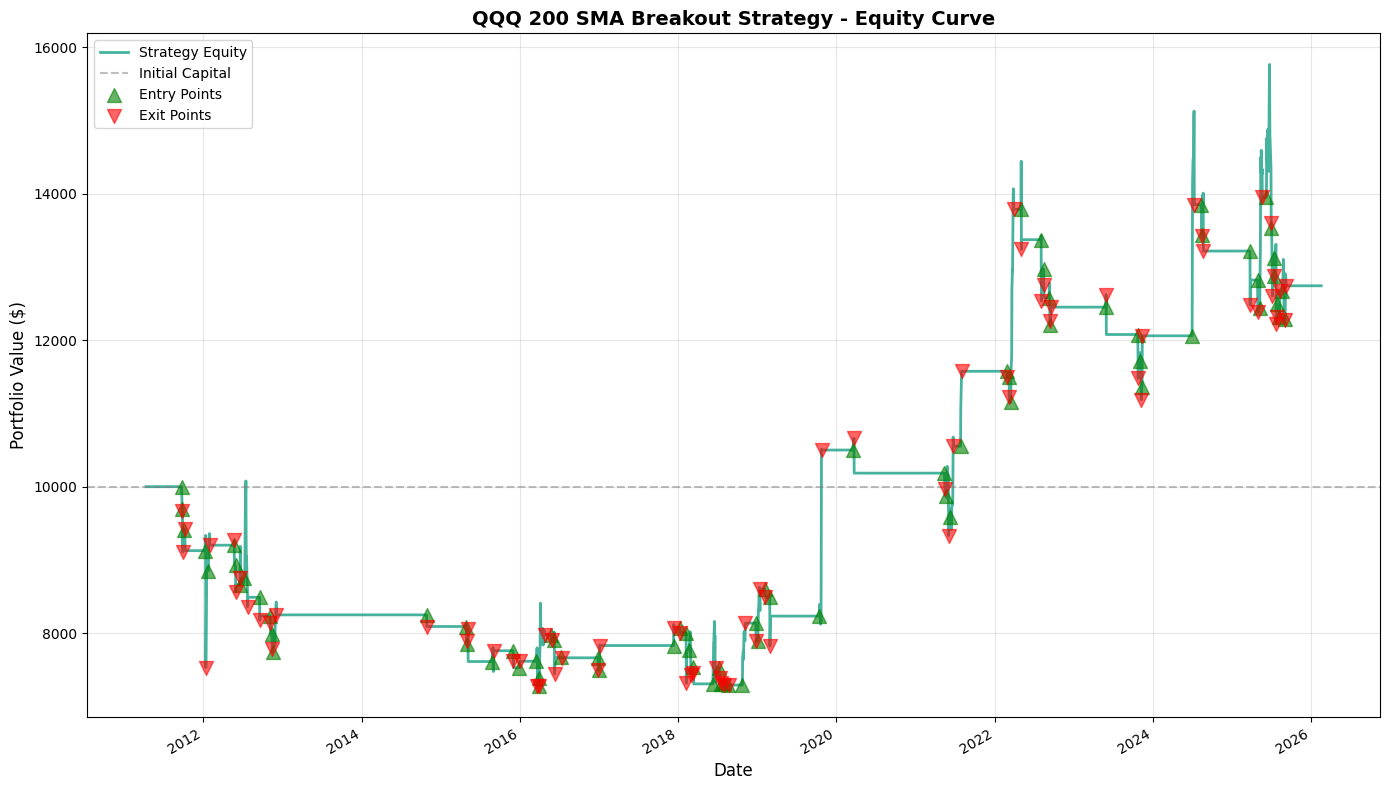

In [130]:
# Equity Curve Plot

# Create plot
plt.figure(figsize=(14, 8))

# Plot strategy equity curve
equity_series.plot(label='Strategy Equity', linewidth=2, color='#16A085', alpha=0.8)

# Add reference line for initial capital
plt.axhline(y=initial_capital, color='gray', linestyle='--', alpha=0.5, label='Initial Capital')

# Mark entry points if trades exist
if len(trades) > 0:
    entry_dates = [t['entry_date'] for t in trades if 'entry_date' in t]
    entry_equity = [equity_series.loc[date] if date in equity_series.index else initial_capital for date in entry_dates]
    plt.scatter(entry_dates, entry_equity, color='green', marker='^', s=100, alpha=0.6, label='Entry Points', zorder=5)
    
    # Mark exit points
    exit_dates = [t['exit_date'] for t in trades if 'exit_date' in t]
    exit_equity = [equity_series.loc[date] if date in equity_series.index else initial_capital for date in exit_dates]
    plt.scatter(exit_dates, exit_equity, color='red', marker='v', s=100, alpha=0.6, label='Exit Points', zorder=5)

plt.title('QQQ 200 SMA Breakout Strategy - Equity Curve', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

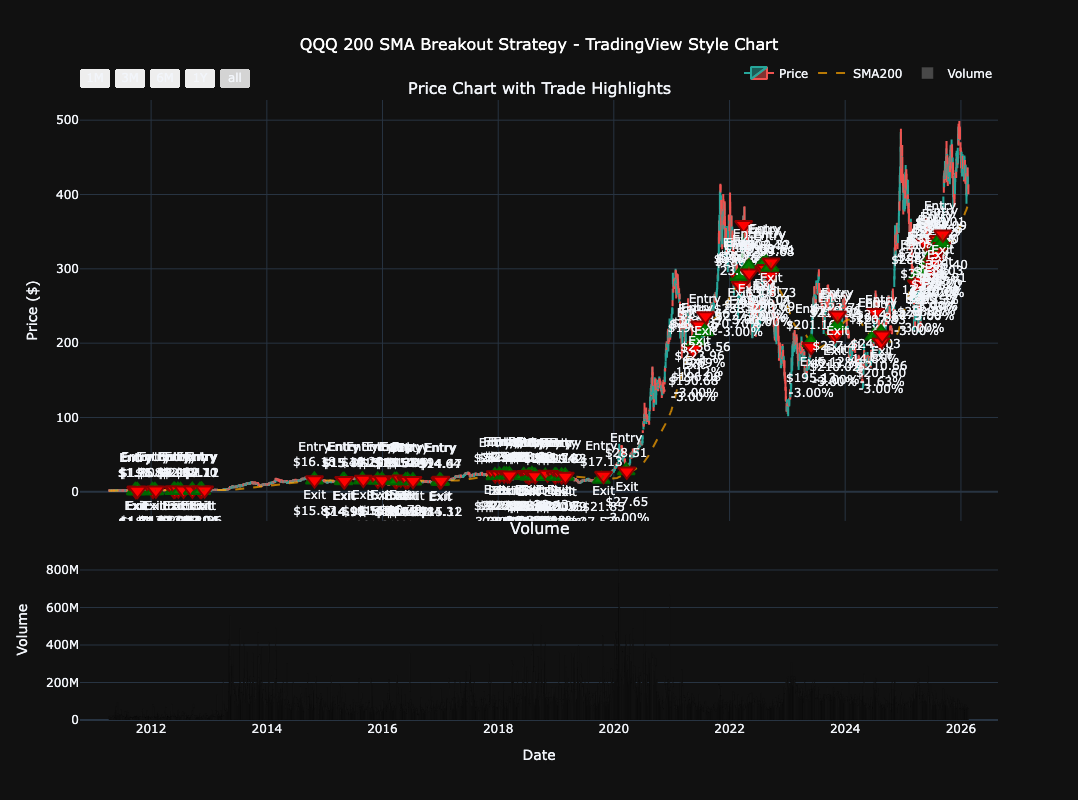


INTERACTIVE CHART DISPLAYED
Use zoom tools (top right) to zoom into specific time periods
Hover over entry/exit markers to see trade details
Green triangles = Entry points
Red triangles = Exit points
Red dotted lines = Stop loss levels
Green/Red dashed lines = Trade connections (green=profit, red=loss)

TRADE LOG (74 trades)
entry_date  entry_price  shares  stop_loss  exit_date  exit_price  pnl_dollar  pnl_pct    exit_reason  hold_days  hold_weeks
2011-09-23         1.76 5686.12       1.71 2011-09-26        1.71     -300.00    -3.00      stop_loss          3         0.4
2011-09-27         1.75 5555.56       1.69 2011-09-28        1.69     -291.00    -3.00      stop_loss          1         0.1
2011-10-06         1.80 5234.98       1.74 2011-10-07        1.74     -282.27    -3.00      stop_loss          1         0.1
2012-01-10         1.84 4956.59       1.79 2012-01-13        1.79     -273.80    -3.00      stop_loss          3         0.4
2012-01-25         1.86 4747.73       1.81 2012

In [131]:
# TradingView-Style Interactive Chart with Trade Highlights

if len(trades) > 0:
    # Prepare data for plotting
    plot_data = data.copy()
    
    # Create subplots: price chart on top, volume on bottom
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.03,
        row_heights=[0.7, 0.3],
        subplot_titles=('Price Chart with Trade Highlights', 'Volume'),
        specs=[[{"secondary_y": False}], [{"secondary_y": False}]]
    )
    
    # Add candlestick chart
    fig.add_trace(
        go.Candlestick(
            x=plot_data.index,
            open=plot_data['Open'],
            high=plot_data['High'],
            low=plot_data['Low'],
            close=plot_data['Close'],
            name='Price',
            increasing_line_color='#26a69a',
            decreasing_line_color='#ef5350'
        ),
        row=1, col=1
    )
    
    # Add 200-day SMA
    if 'SMA200' in plot_data.columns:
        fig.add_trace(
            go.Scatter(
                x=plot_data.index,
                y=plot_data['SMA200'],
                name='SMA200',
                line=dict(color='orange', width=2, dash='dash'),
                opacity=0.7
            ),
            row=1, col=1
        )
    
    # Highlight trades: entry points, stop loss levels, and exit points
    for trade in trades:
        if 'entry_date' in trade and 'exit_date' in trade:
            entry_date = trade['entry_date']
            exit_date = trade['exit_date']
            entry_price = trade['entry_price']
            exit_price = trade.get('exit_price', entry_price)
            stop_loss = trade.get('stop_loss', entry_price * 0.97)
            
            # Get date range for this trade
            trade_mask = (plot_data.index >= entry_date) & (plot_data.index <= exit_date)
            trade_dates = plot_data.index[trade_mask]
            
            if len(trade_dates) > 0:
                # Draw stop loss line for this trade period
                stop_loss_line = pd.Series([stop_loss] * len(trade_dates), index=trade_dates)
                fig.add_trace(
                    go.Scatter(
                        x=stop_loss_line.index,
                        y=stop_loss_line.values,
                        mode='lines',
                        name=f'Stop Loss {entry_date.strftime("%Y-%m-%d")}',
                        line=dict(color='red', width=1, dash='dot'),
                        opacity=0.5,
                        showlegend=False
                    ),
                    row=1, col=1
                )
                
                # Mark entry point
                fig.add_trace(
                    go.Scatter(
                        x=[entry_date],
                        y=[entry_price],
                        mode='markers+text',
                        name='Entry',
                        marker=dict(
                            symbol='triangle-up',
                            size=15,
                            color='green',
                            line=dict(width=2, color='darkgreen')
                        ),
                        text=[f"Entry<br>${entry_price:.2f}"],
                        textposition="top center",
                        showlegend=False,
                        hovertemplate=f'<b>Entry</b><br>Date: %{{x}}<br>Price: ${entry_price:.2f}<br>Stop: ${stop_loss:.2f}<extra></extra>'
                    ),
                    row=1, col=1
                )
                
                # Mark exit point
                exit_reason = trade.get('exit_reason', 'unknown')
                pnl_pct = trade.get('pnl_pct', 0)
                fig.add_trace(
                    go.Scatter(
                        x=[exit_date],
                        y=[exit_price],
                        mode='markers+text',
                        name='Exit',
                        marker=dict(
                            symbol='triangle-down',
                            size=15,
                            color='red',
                            line=dict(width=2, color='darkred')
                        ),
                        text=[f"Exit<br>${exit_price:.2f}<br>{pnl_pct:.2f}%"],
                        textposition="bottom center",
                        showlegend=False,
                        hovertemplate=f'<b>Exit</b><br>Date: %{{x}}<br>Price: ${exit_price:.2f}<br>Reason: {exit_reason}<br>PnL: {pnl_pct:.2f}%<extra></extra>'
                    ),
                    row=1, col=1
                )
                
                # Draw line connecting entry to exit
                fig.add_trace(
                    go.Scatter(
                        x=[entry_date, exit_date],
                        y=[entry_price, exit_price],
                        mode='lines',
                        name=f'Trade {entry_date.strftime("%Y-%m-%d")}',
                        line=dict(
                            color='green' if pnl_pct > 0 else 'red',
                            width=2,
                            dash='dash'
                        ),
                        opacity=0.3,
                        showlegend=False,
                        hovertemplate=f'<b>Trade</b><br>PnL: {pnl_pct:.2f}%<br>Hold: {trade.get("hold_days", 0)} days<extra></extra>'
                    ),
                    row=1, col=1
                )
    
    # Add volume bars
    fig.add_trace(
        go.Bar(
            x=plot_data.index,
            y=plot_data['Volume'],
            name='Volume',
            marker_color='rgba(128, 128, 128, 0.5)'
        ),
        row=2, col=1
    )
    
    # Update layout for TradingView-style appearance
    fig.update_layout(
        title=dict(
            text=f'QQQ 200 SMA Breakout Strategy - TradingView Style Chart',
            x=0.5,
            font=dict(size=16, color='white')
        ),
        xaxis_rangeslider_visible=False,
        height=800,
        template='plotly_dark',
        hovermode='x unified',
        showlegend=True,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        )
    )
    
    # Update axes
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($)", row=1, col=1)
    fig.update_yaxes(title_text="Volume", row=2, col=1)
    
    # Enable zoom and pan with time range selector
    fig.update_layout(
        xaxis=dict(
            rangeselector=dict(
                buttons=list([
                    dict(count=1, label="1M", step="month", stepmode="backward"),
                    dict(count=3, label="3M", step="month", stepmode="backward"),
                    dict(count=6, label="6M", step="month", stepmode="backward"),
                    dict(count=1, label="1Y", step="year", stepmode="backward"),
                    dict(step="all")
                ])
            ),
            rangeslider=dict(visible=False),
            type="date"
        )
    )
    
    fig.show()
    
    print(f"\n{'='*60}")
    print("INTERACTIVE CHART DISPLAYED")
    print(f"{'='*60}")
    print("Use zoom tools (top right) to zoom into specific time periods")
    print("Hover over entry/exit markers to see trade details")
    print("Green triangles = Entry points")
    print("Red triangles = Exit points")
    print("Red dotted lines = Stop loss levels")
    print("Green/Red dashed lines = Trade connections (green=profit, red=loss)")
    print(f"{'='*60}")
else:
    print("No trades to display on chart.")

if len(trades) > 0:
    trades_df = pd.DataFrame(trades)
    
    # Format dates for better readability
    if 'entry_date' in trades_df.columns:
        trades_df['entry_date'] = pd.to_datetime(trades_df['entry_date']).dt.strftime('%Y-%m-%d')
    if 'exit_date' in trades_df.columns:
        trades_df['exit_date'] = pd.to_datetime(trades_df['exit_date']).dt.strftime('%Y-%m-%d')
    
    # Round numeric columns
    numeric_cols = ['entry_price', 'exit_price', 'pnl_dollar', 'pnl_pct', 'shares', 'stop_loss']
    for col in numeric_cols:
        if col in trades_df.columns:
            trades_df[col] = trades_df[col].round(2)
    
    print(f"\n{'='*60}")
    print(f"TRADE LOG ({len(trades_df)} trades)")
    print(f"{'='*60}")
    print(trades_df.to_string(index=False))
    
    # Summary by exit reason
    if 'exit_reason' in trades_df.columns:
        print(f"\n{'='*60}")
        print("TRADES BY EXIT REASON")
        print(f"{'='*60}")
        exit_summary = trades_df.groupby('exit_reason').agg({
            'pnl_pct': ['count', 'mean', 'sum'],
            'hold_days': 'mean'
        }).round(2)
        exit_summary.columns = ['Count', 'Avg PnL %', 'Total PnL %', 'Avg Hold Days']
        print(exit_summary.to_string())
else:
    print("No trades executed.")

In [132]:
# Trade Log Summary

if len(trades) > 0:
    trades_df = pd.DataFrame(trades)
    
    # Format dates for better readability
    if 'entry_date' in trades_df.columns:
        trades_df['entry_date'] = pd.to_datetime(trades_df['entry_date']).dt.strftime('%Y-%m-%d')
    if 'exit_date' in trades_df.columns:
        trades_df['exit_date'] = pd.to_datetime(trades_df['exit_date']).dt.strftime('%Y-%m-%d')
    
    # Round numeric columns
    numeric_cols = ['entry_price', 'exit_price', 'pnl_dollar', 'pnl_pct', 'shares', 'stop_loss']
    for col in numeric_cols:
        if col in trades_df.columns:
            trades_df[col] = trades_df[col].round(2)
    
    print(f"\n{'='*60}")
    print(f"TRADE LOG ({len(trades_df)} trades)")
    print(f"{'='*60}")
    print(trades_df.to_string(index=False))
    
    # Summary by exit reason
    if 'exit_reason' in trades_df.columns:
        print(f"\n{'='*60}")
        print("TRADES BY EXIT REASON")
        print(f"{'='*60}")
        exit_summary = trades_df.groupby('exit_reason').agg({
            'pnl_pct': ['count', 'mean', 'sum'],
            'hold_days': 'mean'
        }).round(2)
        exit_summary.columns = ['Count', 'Avg PnL %', 'Total PnL %', 'Avg Hold Days']
        print(exit_summary.to_string())
else:
    print("No trades executed.")



TRADE LOG (74 trades)
entry_date  entry_price  shares  stop_loss  exit_date  exit_price  pnl_dollar  pnl_pct    exit_reason  hold_days  hold_weeks
2011-09-23         1.76 5686.12       1.71 2011-09-26        1.71     -300.00    -3.00      stop_loss          3         0.4
2011-09-27         1.75 5555.56       1.69 2011-09-28        1.69     -291.00    -3.00      stop_loss          1         0.1
2011-10-06         1.80 5234.98       1.74 2011-10-07        1.74     -282.27    -3.00      stop_loss          1         0.1
2012-01-10         1.84 4956.59       1.79 2012-01-13        1.79     -273.80    -3.00      stop_loss          3         0.4
2012-01-25         1.86 4747.73       1.81 2012-01-31        1.94      348.16     3.93 bearish_signal          6         0.9
2012-05-22         2.05 4481.05       1.99 2012-05-23        1.99     -276.03    -3.00      stop_loss          1         0.1
2012-05-29         2.11 4224.55       2.05 2012-05-30        2.05     -267.75    -3.00      stop_loss 

**Strategy Summary:**

Enter on breakout above 200 SMA. Exit on 3% SL, >8 weeks hold, or strong bearish candle (EveningStar, DarkCloudCover, HangingMan, ShootingStar, Bearish Engulfing, Bearish Harami). Backtested on QQQ historical data.

**Tunable Parameters:**
- `stop_loss_pct`: Stop loss percentage (default: 3%)
- `max_weeks_hold`: Maximum holding period in weeks (default: 8 weeks)
- Bearish patterns list: Can add/remove TA-Lib patterns in the Indicators & Signals cell

---

# Strategy 5: 200 MA Selective Breakout (Long-Only)

**Strategy Overview:**
- **Entry**: When Close > SMA200 AND previous Close <= SMA200 (breakout detected), wait for next day and enter at opening price if next day's Open > SMA200
- **Stop Loss**: Fixed 2% below entry price
- **Exit**: Position held > 8 weeks (≈40 trading days), OR stop loss hit (2% below entry)
- **No bearish candle exits** — removed all pattern-based exits
- **Position Sizing**: $10,000 initial, use full available capital per trade (100% position size)
- **No overlapping positions** — one long at a time

**Key Difference from Original Strategy:**
- Next day entry: When breakout detected, enter at next day's opening price if Open > SMA200
- Simple exit rules: Only stop loss (2%) and time exit (>8 weeks)
- No bearish pattern exits: Removed all candlestick pattern-based exit signals


In [92]:
# Strategy 5: Indicators & Signals for All Tickers

# Prepare data for Strategy 5 for each ticker
data_s5_dict = {}
for ticker in tickers:
    data_s5 = data_dict[ticker].copy()

    # Calculate moving averages
    data_s5['SMA200'] = data_s5['Close'].rolling(window=200, min_periods=200).mean()
    data_s5['SMA60'] = data_s5['Close'].rolling(window=60, min_periods=60).mean()
    
    # Breakout signal: Close > SMA200 AND previous Close <= SMA200 (breakout detected)
    # Entry will be on next day's open if Open > SMA200
    data_s5['Breakout'] = (data_s5['Close'] > data_s5['SMA200']) & (data_s5['Close'].shift(1) <= data_s5['SMA200'].shift(1))
    
    # Next day entry signal: If breakout detected yesterday, check if today's Open > SMA200
    data_s5['NextDay_Entry'] = False
    data_s5.loc[data_s5['Breakout'].shift(1) == True, 'NextDay_Entry'] = (data_s5['Open'] > data_s5['SMA200'])
    
    # Drop rows where SMA200 is NaN (first 200 days)
    data_s5 = data_s5.dropna(subset=['SMA200', 'SMA60'])
    
    data_s5_dict[ticker] = data_s5
    
    print(f"\n{ticker} - Strategy 5 Indicators Calculated")
    print(f"  Breakout signals: {data_s5['Breakout'].sum()}")
    print(f"  Next day entry signals: {data_s5['NextDay_Entry'].sum()}")
    print(f"  Data records: {len(data_s5)}, Date range: {data_s5.index[0]} to {data_s5.index[-1]}")

# For backward compatibility, keep first ticker's data as data_s5
data_s5 = data_s5_dict[tickers[0]]



TSLA - Strategy 5 Indicators Calculated
  Breakout signals: 77
  Next day entry signals: 65
  Data records: 3734, Date range: 2011-04-12 00:00:00 to 2026-02-17 00:00:00

MSFT - Strategy 5 Indicators Calculated
  Breakout signals: 109
  Next day entry signals: 90
  Data records: 6623, Date range: 1999-10-18 00:00:00 to 2026-02-17 00:00:00

AAPL - Strategy 5 Indicators Calculated
  Breakout signals: 49
  Next day entry signals: 41
  Data records: 6623, Date range: 1999-10-18 00:00:00 to 2026-02-17 00:00:00


In [93]:
# Strategy 5: Backtest Function

def backtest_200ma_selective(data, initial_capital=10000.0, stop_loss_pct=0.02, max_weeks_hold=8):
    """
    Backtest Strategy 5: 200 MA Selective Breakout (Long-Only)
    
    Entry: When Close > SMA200 AND previous Close <= SMA200 (breakout detected),
           wait for next day and enter at opening price if next day's Open > SMA200
    Stop Loss: Fixed 2% below entry price
    Exit: >8 weeks hold OR stop loss hit (2% below entry)
    No bearish pattern exits, no SMA60 touch exit
    """
    df = data.copy()
    
    # Ensure required columns exist
    if 'SMA200' not in df.columns:
        df['SMA200'] = df['Close'].rolling(window=200, min_periods=200).mean()
    if 'SMA60' not in df.columns:
        df['SMA60'] = df['Close'].rolling(window=60, min_periods=60).mean()  # For visualization only
    if 'Breakout' not in df.columns:
        df['Breakout'] = (df['Close'] > df['SMA200']) & (df['Close'].shift(1) <= df['SMA200'].shift(1))
    if 'NextDay_Entry' not in df.columns:
        # Next day entry: If breakout detected yesterday, check if today's Open > SMA200
        df['NextDay_Entry'] = False
        df.loc[df['Breakout'].shift(1) == True, 'NextDay_Entry'] = (df['Open'] > df['SMA200'])
    # Touch_SMA60 removed - no longer used as exit condition
    
    # Drop NaN rows (SMA60 still needed for visualization)
    df = df.dropna(subset=['SMA200', 'SMA60'])
    
    # Initialize tracking variables
    capital = initial_capital
    position = 0  # Number of shares held (0 = no position)
    entry_price = 0
    entry_date = None
    stop_loss_price = 0
    trades = []
    equity = []
    dates = []
    
    max_days_hold = max_weeks_hold * 5  # Approximate trading days
    
    # Loop through each trading day
    for idx in range(len(df)):
        date = df.index[idx]
        row = df.iloc[idx]
        current_price = row['Close']
        dates.append(date)
        
        # Calculate current equity (capital + position value)
        if position > 0:
            current_equity = capital + (position * current_price)
        else:
            current_equity = capital
        equity.append(current_equity)
        
        # Entry Logic: Enter on next day's open if breakout was detected yesterday and Open > SMA200
        if position == 0 and row['NextDay_Entry']:
            # Enter at opening price
            entry_price = row['Open']
            
            # Use full available capital for position (100% position size)
            shares = capital / entry_price if entry_price > 0 else 0
            
            if shares > 0:
                stop_loss_price = entry_price * (1 - stop_loss_pct)  # 2% below entry
                entry_date = date
                position = shares
                capital = 0  # All capital is now in position
                
                trades.append({
                    'entry_date': date,
                    'entry_price': entry_price,
                    'shares': shares,
                    'stop_loss': stop_loss_price
                })
        
        # Exit Logic: Check if we have an open position
        elif position > 0:
            days_held = (date - entry_date).days
            weeks_held = days_held / 7.0
            
            # Check exit conditions
            exit_reason = None
            exit_price = current_price  # Default exit at close
            
            # Exit 1: Stop loss hit (price drops to or below stop loss)
            if row['Low'] <= stop_loss_price:
                exit_reason = 'stop_loss'
                exit_price = stop_loss_price  # Exit at stop loss price
            
            # Exit 2: Maximum holding period exceeded (> 8 weeks)
            elif weeks_held > max_weeks_hold:
                exit_reason = 'time_exit'
            
            # Note: SMA60 touch exit removed - only stop loss and time exit remain
            
            # Execute exit if any condition is met
            if exit_reason:
                # Calculate P&L
                pnl_dollar = position * (exit_price - entry_price)
                pnl_pct = ((exit_price / entry_price) - 1) * 100
                
                # Close position
                capital = capital + (position * exit_price)
                position = 0
                
                # Update trade record
                trades[-1].update({
                    'exit_date': date,
                    'exit_price': exit_price,
                    'pnl_dollar': pnl_dollar,
                    'pnl_pct': pnl_pct,
                    'exit_reason': exit_reason,
                    'hold_days': days_held,
                    'hold_weeks': round(weeks_held, 1)
                })
    
    # Handle any open position at the end of data
    if position > 0:
        final_price = df['Close'].iloc[-1]
        pnl_dollar = position * (final_price - entry_price)
        pnl_pct = ((final_price / entry_price) - 1) * 100
        capital = capital + (position * final_price)
        
        trades[-1].update({
            'exit_date': df.index[-1],
            'exit_price': final_price,
            'pnl_dollar': pnl_dollar,
            'pnl_pct': pnl_pct,
            'exit_reason': 'end_of_data',
            'hold_days': (df.index[-1] - entry_date).days,
            'hold_weeks': round((df.index[-1] - entry_date).days / 7.0, 1)
        })
    
    # Create equity series
    equity_series = pd.Series(equity, index=dates[:len(equity)])
    
    # Calculate final metrics
    final_capital = capital + (position * df['Close'].iloc[-1] if position > 0 else 0)
    total_return = ((final_capital / initial_capital) - 1) * 100
    num_trades = len([t for t in trades if 'exit_date' in t])
    
    # Calculate additional metrics
    if num_trades > 0:
        completed_trades = [t for t in trades if 'exit_date' in t]
        winning_trades = [t for t in completed_trades if t['pnl_dollar'] > 0]
        losing_trades = [t for t in completed_trades if t['pnl_dollar'] <= 0]
        
        win_rate = (len(winning_trades) / num_trades) * 100 if num_trades > 0 else 0
        avg_win = np.mean([t['pnl_pct'] for t in winning_trades]) if winning_trades else 0
        avg_loss = np.mean([t['pnl_pct'] for t in losing_trades]) if losing_trades else 0
        
        # Max drawdown
        equity_array = np.array(equity)
        running_max = np.maximum.accumulate(equity_array)
        drawdown = (equity_array - running_max) / running_max * 100
        max_drawdown = drawdown.min()
        
        # Sharpe ratio (risk-free rate = 0%, using daily returns)
        daily_returns = equity_series.pct_change().dropna()
        if len(daily_returns) > 0 and daily_returns.std() > 0:
            sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)  # Annualized
        else:
            sharpe_ratio = 0
    else:
        win_rate = 0
        avg_win = 0
        avg_loss = 0
        max_drawdown = 0
        sharpe_ratio = 0
    
    # Calculate Buy & Hold return
    buy_hold_start_price = df['Adj Close'].iloc[0] if 'Adj Close' in df.columns else df['Close'].iloc[0]
    buy_hold_end_price = df['Adj Close'].iloc[-1] if 'Adj Close' in df.columns else df['Close'].iloc[-1]
    buy_hold_return = ((buy_hold_end_price / buy_hold_start_price) - 1) * 100
    
    results = {
        'initial_capital': initial_capital,
        'final_capital': final_capital,
        'total_return': total_return,
        'num_trades': num_trades,
        'win_rate': win_rate,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'max_drawdown': max_drawdown,
        'sharpe_ratio': sharpe_ratio,
        'buy_hold_return': buy_hold_return,
        'trades': trades,
        'equity_curve': equity_series,
        'dates': dates
    }
    
    return results

# Run backtest for all tickers
print("Running Strategy 5 backtest for all tickers...")
print("="*60)

results_s5_dict = {}
for ticker in tickers:
    print(f"\n{'='*60}")
    print(f"Running backtest for {ticker}...")
    print(f"{'='*60}")
    results_s5 = backtest_200ma_selective(data_s5_dict[ticker], initial_capital=10000.0, stop_loss_pct=0.02, max_weeks_hold=8)
    results_s5_dict[ticker] = results_s5
    
    # Print results for this ticker
    print(f"\n{ticker} - STRATEGY 5 BACKTEST RESULTS")
    print(f"Initial Capital: ${results_s5['initial_capital']:,.2f}")
    print(f"Final Capital: ${results_s5['final_capital']:,.2f}")
    print(f"Total Return: {results_s5['total_return']:.2f}%")
    print(f"Total Trades: {results_s5['num_trades']}")
    if results_s5['num_trades'] > 0:
        print(f"Win Rate: {results_s5['win_rate']:.2f}%")
        print(f"Average Win: {results_s5['avg_win']:.2f}%")
        print(f"Average Loss: {results_s5['avg_loss']:.2f}%")
        print(f"Max Drawdown: {results_s5['max_drawdown']:.2f}%")
        print(f"Sharpe Ratio: {results_s5['sharpe_ratio']:.2f}")
    print(f"Buy & Hold Return: {results_s5['buy_hold_return']:.2f}%")

# For backward compatibility, keep first ticker's results as results_s5
results_s5 = results_s5_dict[tickers[0]]

# Print summary comparison
print(f"\n{'='*60}")
print("SUMMARY COMPARISON - ALL TICKERS")
print(f"{'='*60}")
summary_data = []
for ticker in tickers:
    r = results_s5_dict[ticker]
    summary_data.append({
        'Ticker': ticker,
        'Final Capital': f"${r['final_capital']:,.2f}",
        'Total Return': f"{r['total_return']:.2f}%",
        'Trades': r['num_trades'],
        'Win Rate': f"{r['win_rate']:.2f}%" if r['num_trades'] > 0 else "N/A",
        'Buy & Hold': f"{r['buy_hold_return']:.2f}%"
    })
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print(f"{'='*60}")


Running Strategy 5 backtest for all tickers...

Running backtest for TSLA...

TSLA - STRATEGY 5 BACKTEST RESULTS
Initial Capital: $10,000.00
Final Capital: $19,409.18
Total Return: 94.09%
Total Trades: 63
Win Rate: 12.70%
Average Win: 25.72%
Average Loss: -2.00%
Max Drawdown: -38.53%
Sharpe Ratio: 0.31
Buy & Hold Return: 24887.63%

Running backtest for MSFT...

MSFT - STRATEGY 5 BACKTEST RESULTS
Initial Capital: $10,000.00
Final Capital: $31,092.73
Total Return: 210.93%
Total Trades: 72
Win Rate: 30.56%
Average Win: 10.37%
Average Loss: -1.96%
Max Drawdown: -26.30%
Sharpe Ratio: 0.44
Buy & Hold Return: 1378.64%

Running backtest for AAPL...

AAPL - STRATEGY 5 BACKTEST RESULTS
Initial Capital: $10,000.00
Final Capital: $32,835.99
Total Return: 228.36%
Total Trades: 37
Win Rate: 37.84%
Average Win: 12.68%
Average Loss: -2.00%
Max Drawdown: -21.82%
Sharpe Ratio: 0.47
Buy & Hold Return: 47992.06%

SUMMARY COMPARISON - ALL TICKERS
Ticker Final Capital Total Return  Trades Win Rate Buy & Hol

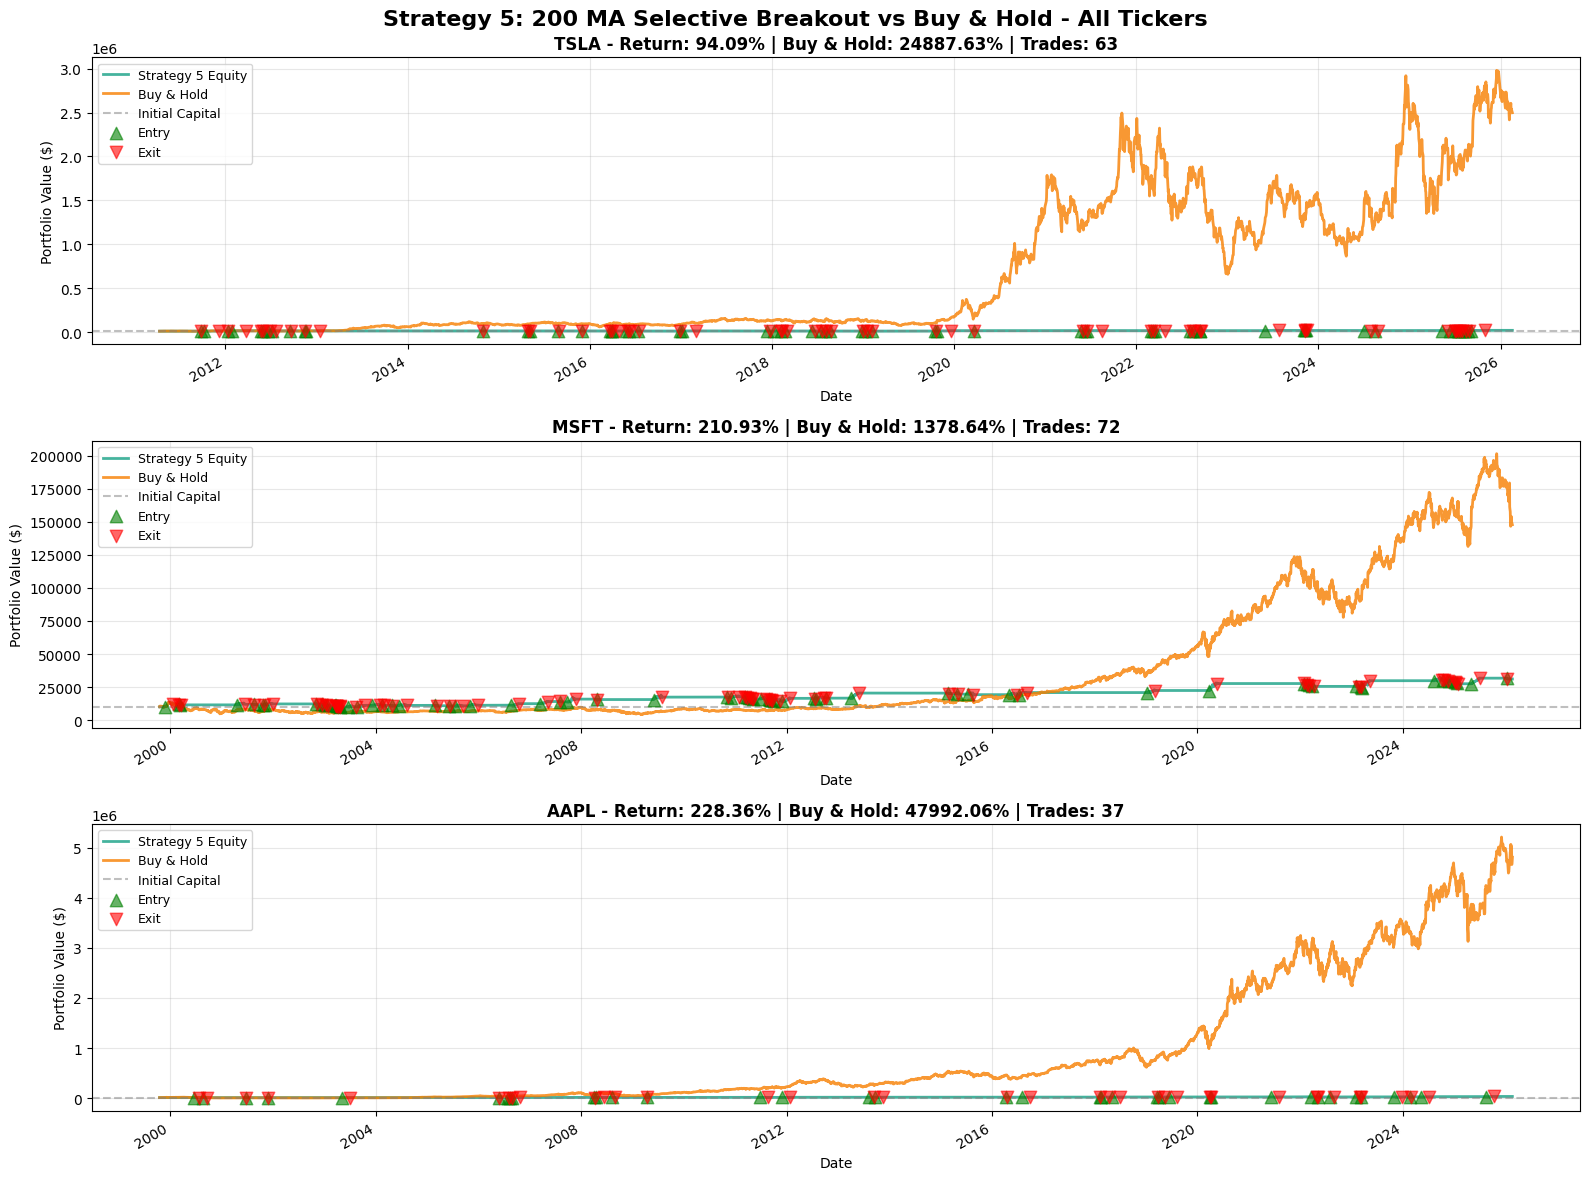


STRATEGY COMPARISON - ALL TICKERS

TSLA:
  Strategy Return: 94.09%
  Buy & Hold Return: 24887.63%
  Difference: -24793.54%

MSFT:
  Strategy Return: 210.93%
  Buy & Hold Return: 1378.64%
  Difference: -1167.71%

AAPL:
  Strategy Return: 228.36%
  Buy & Hold Return: 47992.06%
  Difference: -47763.70%


In [94]:
# Strategy 5: Equity Curve Plots for All Tickers

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Strategy 5: 200 MA Selective Breakout vs Buy & Hold - All Tickers', fontsize=16, fontweight='bold')

for idx, ticker in enumerate(tickers):
    ax = axes[idx]
    data_ticker = data_s5_dict[ticker]
    results_ticker = results_s5_dict[ticker]
    
    # Calculate Buy & Hold equity curve
    buy_hold_start_price = data_ticker['Adj Close'].iloc[0] if 'Adj Close' in data_ticker.columns else data_ticker['Close'].iloc[0]
    buy_hold_equity = (data_ticker['Adj Close'] / buy_hold_start_price * results_ticker['initial_capital']) if 'Adj Close' in data_ticker.columns else (data_ticker['Close'] / buy_hold_start_price * results_ticker['initial_capital'])
    
    # Plot strategy equity curve
    results_ticker['equity_curve'].plot(ax=ax, label='Strategy 5 Equity', linewidth=2, color='#16A085', alpha=0.8)
    
    # Plot Buy & Hold equity curve
    buy_hold_equity.plot(ax=ax, label='Buy & Hold', linewidth=2, color='#F77F00', alpha=0.8)
    
    # Add reference line for initial capital
    ax.axhline(y=results_ticker['initial_capital'], color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
    
    # Mark entry and exit points if trades exist
    if len(results_ticker['trades']) > 0:
        entry_dates = [t['entry_date'] for t in results_ticker['trades'] if 'entry_date' in t]
        entry_equity = [results_ticker['equity_curve'].loc[date] if date in results_ticker['equity_curve'].index else results_ticker['initial_capital'] for date in entry_dates]
        ax.scatter(entry_dates, entry_equity, color='green', marker='^', s=80, alpha=0.6, label='Entry', zorder=5)
        
        exit_dates = [t['exit_date'] for t in results_ticker['trades'] if 'exit_date' in t]
        exit_equity = [results_ticker['equity_curve'].loc[date] if date in results_ticker['equity_curve'].index else results_ticker['initial_capital'] for date in exit_dates]
        ax.scatter(exit_dates, exit_equity, color='red', marker='v', s=80, alpha=0.6, label='Exit', zorder=5)
    
    ax.set_title(f'{ticker} - Return: {results_ticker["total_return"]:.2f}% | Buy & Hold: {results_ticker["buy_hold_return"]:.2f}% | Trades: {results_ticker["num_trades"]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Portfolio Value ($)', fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison for all tickers
print(f"\n{'='*60}")
print("STRATEGY COMPARISON - ALL TICKERS")
print(f"{'='*60}")
for ticker in tickers:
    r = results_s5_dict[ticker]
    print(f"\n{ticker}:")
    print(f"  Strategy Return: {r['total_return']:.2f}%")
    print(f"  Buy & Hold Return: {r['buy_hold_return']:.2f}%")
    print(f"  Difference: {r['total_return'] - r['buy_hold_return']:.2f}%")
print(f"{'='*60}")


In [95]:
# Strategy 5: TradingView-Style Charts for All Tickers

for ticker in tickers:
    results_ticker = results_s5_dict[ticker]
    
    if len(results_ticker['trades']) > 0:
        # Prepare data for plotting
        plot_data_s5 = data_s5_dict[ticker].copy()
        
        # Create subplots: price chart on top, volume on bottom
        fig_s5 = make_subplots(
            rows=2, cols=1,
            shared_xaxes=True,
            vertical_spacing=0.03,
            row_heights=[0.7, 0.3],
            subplot_titles=(f'{ticker} - Strategy 5: Price Chart with Trade Highlights', 'Volume'),
            specs=[[{"secondary_y": False}], [{"secondary_y": False}]]
        )
    
    # Add candlestick chart
    fig_s5.add_trace(
        go.Candlestick(
            x=plot_data_s5.index,
            open=plot_data_s5['Open'],
            high=plot_data_s5['High'],
            low=plot_data_s5['Low'],
            close=plot_data_s5['Close'],
            name='Price',
            increasing_line_color='#26a69a',
            decreasing_line_color='#ef5350'
        ),
        row=1, col=1
    )
    
    # Add 200-day SMA
    if 'SMA200' in plot_data_s5.columns:
        fig_s5.add_trace(
            go.Scatter(
                x=plot_data_s5.index,
                y=plot_data_s5['SMA200'],
                name='SMA200',
                line=dict(color='orange', width=2, dash='dash'),
                opacity=0.7
            ),
            row=1, col=1
        )
    
    # Add 60-day SMA
    if 'SMA60' in plot_data_s5.columns:
        fig_s5.add_trace(
            go.Scatter(
                x=plot_data_s5.index,
                y=plot_data_s5['SMA60'],
                name='SMA60',
                line=dict(color='blue', width=2, dash='dot'),
                opacity=0.7
            ),
            row=1, col=1
        )
    
        # Highlight trades: entry points, stop loss levels, and exit points
        for trade in results_ticker['trades']:
            if 'entry_date' in trade and 'exit_date' in trade:
            entry_date = trade['entry_date']
            exit_date = trade['exit_date']
            entry_price = trade['entry_price']
            exit_price = trade.get('exit_price', entry_price)
            stop_loss = trade.get('stop_loss', entry_price * 0.97)
            
            # Get date range for this trade
            trade_mask = (plot_data_s5.index >= entry_date) & (plot_data_s5.index <= exit_date)
            trade_dates = plot_data_s5.index[trade_mask]
            
            if len(trade_dates) > 0:
                # Draw stop loss line for this trade period
                stop_loss_line = pd.Series([stop_loss] * len(trade_dates), index=trade_dates)
                fig_s5.add_trace(
                    go.Scatter(
                        x=stop_loss_line.index,
                        y=stop_loss_line.values,
                        mode='lines',
                        name=f'Stop Loss {entry_date.strftime("%Y-%m-%d")}',
                        line=dict(color='red', width=1, dash='dot'),
                        opacity=0.5,
                        showlegend=False
                    ),
                    row=1, col=1
                )
                
                # Mark entry point
                fig_s5.add_trace(
                    go.Scatter(
                        x=[entry_date],
                        y=[entry_price],
                        mode='markers+text',
                        name='Entry',
                        marker=dict(
                            symbol='triangle-up',
                            size=15,
                            color='green',
                            line=dict(width=2, color='darkgreen')
                        ),
                        text=[f"Entry<br>${entry_price:.2f}"],
                        textposition="top center",
                        showlegend=False,
                        hovertemplate=f'<b>Entry</b><br>Date: %{{x}}<br>Price: ${entry_price:.2f}<br>Stop: ${stop_loss:.2f}<extra></extra>'
                    ),
                    row=1, col=1
                )
                
                # Mark exit point
                exit_reason = trade.get('exit_reason', 'unknown')
                pnl_pct = trade.get('pnl_pct', 0)
                fig_s5.add_trace(
                    go.Scatter(
                        x=[exit_date],
                        y=[exit_price],
                        mode='markers+text',
                        name='Exit',
                        marker=dict(
                            symbol='triangle-down',
                            size=15,
                            color='red',
                            line=dict(width=2, color='darkred')
                        ),
                        text=[f"Exit<br>${exit_price:.2f}<br>{pnl_pct:.2f}%"],
                        textposition="bottom center",
                        showlegend=False,
                        hovertemplate=f'<b>Exit</b><br>Date: %{{x}}<br>Price: ${exit_price:.2f}<br>Reason: {exit_reason}<br>PnL: {pnl_pct:.2f}%<extra></extra>'
                    ),
                    row=1, col=1
                )
                
                # Draw line connecting entry to exit
                fig_s5.add_trace(
                    go.Scatter(
                        x=[entry_date, exit_date],
                        y=[entry_price, exit_price],
                        mode='lines',
                        name=f'Trade {entry_date.strftime("%Y-%m-%d")}',
                        line=dict(
                            color='green' if pnl_pct > 0 else 'red',
                            width=2,
                            dash='dash'
                        ),
                        opacity=0.3,
                        showlegend=False,
                        hovertemplate=f'<b>Trade</b><br>PnL: {pnl_pct:.2f}%<br>Hold: {trade.get("hold_days", 0)} days<br>Reason: {exit_reason}<extra></extra>'
                    ),
                    row=1, col=1
                )
    
    # Add volume bars
    fig_s5.add_trace(
        go.Bar(
            x=plot_data_s5.index,
            y=plot_data_s5['Volume'],
            name='Volume',
            marker_color='rgba(128, 128, 128, 0.5)'
        ),
        row=2, col=1
    )
    
        # Update layout for TradingView-style appearance
        fig_s5.update_layout(
            title=dict(
                text=f'{ticker} - Strategy 5: 200 MA Selective Breakout - TradingView Style Chart',
                x=0.5,
                font=dict(size=16, color='white')
            ),
        xaxis_rangeslider_visible=False,
        height=800,
        template='plotly_dark',
        hovermode='x unified',
        showlegend=True,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        )
    )
    
    # Update axes
    fig_s5.update_xaxes(title_text="Date", row=2, col=1)
    fig_s5.update_yaxes(title_text="Price ($)", row=1, col=1)
    fig_s5.update_yaxes(title_text="Volume", row=2, col=1)
    
    # Enable zoom and pan with time range selector
    fig_s5.update_layout(
        xaxis=dict(
            rangeselector=dict(
                buttons=list([
                    dict(count=1, label="1M", step="month", stepmode="backward"),
                    dict(count=3, label="3M", step="month", stepmode="backward"),
                    dict(count=6, label="6M", step="month", stepmode="backward"),
                    dict(count=1, label="1Y", step="year", stepmode="backward"),
                    dict(step="all")
                ])
            ),
            rangeslider=dict(visible=False),
            type="date"
        )
    )
    
        fig_s5.show()
        
        print(f"\n{'='*60}")
        print(f"{ticker} - INTERACTIVE CHART DISPLAYED")
        print(f"{'='*60}")
        print("Use zoom tools (top right) to zoom into specific time periods")
        print("Hover over entry/exit markers to see trade details")
        print("Green triangles = Entry points")
        print("Red triangles = Exit points")
        print("Red dotted lines = Stop loss levels")
        print("Orange dashed line = SMA200")
        print("Blue dotted line = SMA60")
        print("Green/Red dashed lines = Trade connections (green=profit, red=loss)")
        print(f"{'='*60}")
    else:
        print(f"\n{ticker}: No trades to display on chart.")


IndentationError: expected an indented block (4189089233.py, line 64)

In [ ]:
# Strategy 5: Trade Log Summary for All Tickers

for ticker in tickers:
    results_ticker = results_s5_dict[ticker]
    
    if len(results_ticker['trades']) > 0:
        trades_df_s5 = pd.DataFrame(results_ticker['trades'])
        
        # Format dates for better readability
        if 'entry_date' in trades_df_s5.columns:
            trades_df_s5['entry_date'] = pd.to_datetime(trades_df_s5['entry_date']).dt.strftime('%Y-%m-%d')
        if 'exit_date' in trades_df_s5.columns:
            trades_df_s5['exit_date'] = pd.to_datetime(trades_df_s5['exit_date']).dt.strftime('%Y-%m-%d')
        
        # Round numeric columns
        numeric_cols = ['entry_price', 'exit_price', 'pnl_dollar', 'pnl_pct', 'shares', 'stop_loss']
        for col in numeric_cols:
            if col in trades_df_s5.columns:
                trades_df_s5[col] = trades_df_s5[col].round(2)
        
        print(f"\n{'='*60}")
        print(f"{ticker} - STRATEGY 5 TRADE LOG ({len(trades_df_s5)} trades)")
        print(f"{'='*60}")
        print(trades_df_s5.to_string(index=False))
        
        # Summary by exit reason
        if 'exit_reason' in trades_df_s5.columns:
            print(f"\n{ticker} - TRADES BY EXIT REASON")
            print(f"{'='*60}")
            exit_summary_s5 = trades_df_s5.groupby('exit_reason').agg({
                'pnl_pct': ['count', 'mean', 'sum'],
                'hold_days': 'mean'
            }).round(2)
            exit_summary_s5.columns = ['Count', 'Avg PnL %', 'Total PnL %', 'Avg Hold Days']
            print(exit_summary_s5.to_string())
    else:
        print(f"\n{ticker}: No trades executed.")


---

# Strategy 6: 200 SMA Breakout with Regime Filter (Long-Only)

**Strategy Overview:**
- **Regime Filter**: ADX(14) > 25 (strong trend) on breakout day — skip if < 25 (choppy/non-trending)
- **Entry**: Breakout detected (Close > SMA200 & prev Close <= SMA200), then next day: Enter at Open if Open > SMA200 AND ADX > 25
- **Stop Loss**: Fixed 5% below entry price (looser to avoid volatility stops)
- **Exit**: Stop hit, OR price touches downward to SMA60 (Low <= SMA60) — allows dynamic longer holds in trends
- **Position Sizing**: Full available capital per trade (100% position size)
- **No overlapping positions** — one long at a time
- **No bearish pattern exits** — removed all pattern-based exits

**Key Enhancements from Strategy 5:**
- ADX regime filter: Only enter in strong trending markets (ADX > 25), reducing whipsaws around SMA200
- Looser stop: 5% stop loss (vs 2%) for breathing room in volatile markets
- Dynamic exit: Exit on SMA60 touch instead of fixed 8 weeks, allowing longer winners in trends


In [108]:
# Strategy 6: Indicators & Signals with ADX Regime Filter

# Prepare data for Strategy 6 for each ticker
data_s6_dict = {}
for ticker in tickers:
    data_s6 = data_dict[ticker].copy()
    
    # Calculate moving averages (reuse from Strategy 5 if available)
    if 'SMA200' not in data_s6.columns:
        data_s6['SMA200'] = data_s6['Close'].rolling(window=200, min_periods=200).mean()
    if 'SMA60' not in data_s6.columns:
        data_s6['SMA60'] = data_s6['Close'].rolling(window=60, min_periods=60).mean()
    
    # Calculate ADX(14) for regime filter
    data_s6['ADX'] = talib.ADX(data_s6['High'].values, data_s6['Low'].values, data_s6['Close'].values, timeperiod=14)
    
    # Breakout signal: Close > SMA200 AND previous Close <= SMA200 (breakout detected)
    data_s6['Breakout'] = (data_s6['Close'] > data_s6['SMA200']) & (data_s6['Close'].shift(1) <= data_s6['SMA200'].shift(1))
    
    # Next day entry signal: If breakout detected yesterday, check if today's Open > SMA200 AND ADX > 25 (regime filter)
    # Check ADX on breakout day (yesterday) - shift(1) gets yesterday's ADX
    data_s6['NextDay_Entry'] = False
    breakout_yesterday = data_s6['Breakout'].shift(1) == True
    adx_strong_trend = data_s6['ADX'].shift(1) > 25  # ADX on breakout day
    open_above_sma = data_s6['Open'] > data_s6['SMA200']
    data_s6.loc[breakout_yesterday & adx_strong_trend & open_above_sma, 'NextDay_Entry'] = True
    
    # Touch SMA60: Low touches or goes below SMA60 (for exit)
    data_s6['Touch_SMA60'] = data_s6['Low'] <= data_s6['SMA60']
    
    # Drop rows where SMA200, SMA60, or ADX is NaN
    data_s6 = data_s6.dropna(subset=['SMA200', 'SMA60', 'ADX'])
    
    data_s6_dict[ticker] = data_s6
    
    print(f"\n{ticker} - Strategy 6 Indicators Calculated")
    print(f"  Breakout signals: {data_s6['Breakout'].sum()}")
    print(f"  Breakouts with ADX > 25: {(data_s6['Breakout'] & (data_s6['ADX'] > 25)).sum()}")
    print(f"  Next day entry signals (Open > SMA200 & ADX > 25): {data_s6['NextDay_Entry'].sum()}")
    print(f"  SMA60 touch signals: {data_s6['Touch_SMA60'].sum()}")
    print(f"  Data records: {len(data_s6)}, Date range: {data_s6.index[0]} to {data_s6.index[-1]}")

print(f"\n{'='*60}")
print("Strategy 6 indicators calculated for all tickers")
print(f"{'='*60}")



TSLA - Strategy 6 Indicators Calculated
  Breakout signals: 77
  Breakouts with ADX > 25: 22
  Next day entry signals (Open > SMA200 & ADX > 25): 21
  SMA60 touch signals: 1790
  Data records: 3734, Date range: 2011-04-12 00:00:00 to 2026-02-17 00:00:00

MSFT - Strategy 6 Indicators Calculated
  Breakout signals: 109
  Breakouts with ADX > 25: 34
  Next day entry signals (Open > SMA200 & ADX > 25): 27
  SMA60 touch signals: 2928
  Data records: 6623, Date range: 1999-10-18 00:00:00 to 2026-02-17 00:00:00

AAPL - Strategy 6 Indicators Calculated
  Breakout signals: 49
  Breakouts with ADX > 25: 26
  Next day entry signals (Open > SMA200 & ADX > 25): 21
  SMA60 touch signals: 2566
  Data records: 6623, Date range: 1999-10-18 00:00:00 to 2026-02-17 00:00:00

Strategy 6 indicators calculated for all tickers


In [109]:
# Strategy 6: Backtest Function with Regime Filter

def backtest_regime_filtered(data, initial_capital=10000.0, stop_loss_pct=0.03, adx_threshold=25):
    """
    Backtest Strategy 6: 200 MA Breakout with Regime Filter (Long-Only)
    
    Entry: When Close > SMA200 AND previous Close <= SMA200 (breakout detected),
           wait for next day and enter at opening price if:
           - Open > SMA200 AND
           - ADX on breakout day > 25 (strong trend regime)
    Stop Loss: Fixed 5% below entry price
    Exit: Stop hit OR Low <= SMA60 (touch downward to 60 SMA)
    No bearish pattern exits
    """
    df = data.copy()
    
    # Ensure required columns exist
    if 'SMA200' not in df.columns:
        df['SMA200'] = df['Close'].rolling(window=200, min_periods=200).mean()
    if 'SMA60' not in df.columns:
        df['SMA60'] = df['Close'].rolling(window=60, min_periods=60).mean()
    if 'ADX' not in df.columns:
        df['ADX'] = talib.ADX(df['High'].values, df['Low'].values, df['Close'].values, timeperiod=14)
    if 'Breakout' not in df.columns:
        df['Breakout'] = (df['Close'] > df['SMA200']) & (df['Close'].shift(1) <= df['SMA200'].shift(1))
    if 'NextDay_Entry' not in df.columns:
        breakout_yesterday = df['Breakout'].shift(1) == True
        adx_strong_trend = df['ADX'].shift(1) > adx_threshold
        open_above_sma = df['Open'] > df['SMA200']
        df['NextDay_Entry'] = False
        df.loc[breakout_yesterday & adx_strong_trend & open_above_sma, 'NextDay_Entry'] = True
    if 'Touch_SMA60' not in df.columns:
        df['Touch_SMA60'] = df['Low'] <= df['SMA60']
    
    # Drop NaN rows
    df = df.dropna(subset=['SMA200', 'SMA60', 'ADX'])
    
    # Initialize tracking variables
    capital = initial_capital
    position = 0  # Number of shares held (0 = no position)
    entry_price = 0
    entry_date = None
    stop_loss_price = 0
    trades = []
    equity = []
    dates = []
    
    # Loop through each trading day
    for idx in range(len(df)):
        date = df.index[idx]
        row = df.iloc[idx]
        current_price = row['Close']
        dates.append(date)
        
        # Calculate current equity (capital + position value)
        if position > 0:
            current_equity = capital + (position * current_price)
        else:
            current_equity = capital
        equity.append(current_equity)
        
        # Entry Logic: Enter on next day's open if breakout was detected yesterday, Open > SMA200, and ADX > 25
        if position == 0 and row['NextDay_Entry']:
            # Enter at opening price
            entry_price = row['Open']
            
            # Use full available capital for position (100% position size)
            shares = capital / entry_price if entry_price > 0 else 0
            
            if shares > 0:
                stop_loss_price = entry_price * (1 - stop_loss_pct)  # 5% below entry
                entry_date = date
                position = shares
                capital = 0  # All capital is now in position
                
                trades.append({
                    'entry_date': date,
                    'entry_price': entry_price,
                    'shares': shares,
                    'stop_loss': stop_loss_price
                })
        
        # Exit Logic: Check if we have an open position
        elif position > 0:
            days_held = (date - entry_date).days
            
            # Check exit conditions
            exit_reason = None
            exit_price = current_price  # Default exit at close
            
            # Exit 1: Stop loss hit (price drops to or below stop loss)
            if row['Low'] <= stop_loss_price:
                exit_reason = 'stop_loss'
                exit_price = stop_loss_price  # Exit at stop loss price
            
            # Exit 2: Price touches downward to SMA60 (Low <= SMA60)
            elif row['Touch_SMA60']:
                exit_reason = 'sma60_touch'
            
            # Execute exit if any condition is met
            if exit_reason:
                # Calculate P&L
                pnl_dollar = position * (exit_price - entry_price)
                pnl_pct = ((exit_price / entry_price) - 1) * 100
                
                # Close position
                capital = capital + (position * exit_price)
                position = 0
                
                # Update trade record
                trades[-1].update({
                    'exit_date': date,
                    'exit_price': exit_price,
                    'pnl_dollar': pnl_dollar,
                    'pnl_pct': pnl_pct,
                    'exit_reason': exit_reason,
                    'hold_days': days_held,
                    'hold_weeks': round(days_held / 7.0, 1)
                })
    
    # Handle any open position at the end of data
    if position > 0:
        final_price = df['Close'].iloc[-1]
        pnl_dollar = position * (final_price - entry_price)
        pnl_pct = ((final_price / entry_price) - 1) * 100
        capital = capital + (position * final_price)
        
        trades[-1].update({
            'exit_date': df.index[-1],
            'exit_price': final_price,
            'pnl_dollar': pnl_dollar,
            'pnl_pct': pnl_pct,
            'exit_reason': 'end_of_data',
            'hold_days': (df.index[-1] - entry_date).days,
            'hold_weeks': round((df.index[-1] - entry_date).days / 7.0, 1)
        })
    
    # Create equity series
    equity_series = pd.Series(equity, index=dates[:len(equity)])
    
    # Calculate final metrics
    final_capital = capital + (position * df['Close'].iloc[-1] if position > 0 else 0)
    total_return = ((final_capital / initial_capital) - 1) * 100
    num_trades = len([t for t in trades if 'exit_date' in t])
    
    # Calculate additional metrics
    if num_trades > 0:
        completed_trades = [t for t in trades if 'exit_date' in t]
        winning_trades = [t for t in completed_trades if t['pnl_dollar'] > 0]
        losing_trades = [t for t in completed_trades if t['pnl_dollar'] <= 0]
        
        win_rate = (len(winning_trades) / num_trades) * 100 if num_trades > 0 else 0
        avg_win = np.mean([t['pnl_pct'] for t in winning_trades]) if winning_trades else 0
        avg_loss = np.mean([t['pnl_pct'] for t in losing_trades]) if losing_trades else 0
        
        # Max drawdown
        equity_array = np.array(equity)
        running_max = np.maximum.accumulate(equity_array)
        drawdown = (equity_array - running_max) / running_max * 100
        max_drawdown = drawdown.min()
        
        # Sharpe ratio (risk-free rate = 0%, using daily returns)
        daily_returns = equity_series.pct_change().dropna()
        if len(daily_returns) > 0 and daily_returns.std() > 0:
            sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)  # Annualized
        else:
            sharpe_ratio = 0
    else:
        win_rate = 0
        avg_win = 0
        avg_loss = 0
        max_drawdown = 0
        sharpe_ratio = 0
    
    # Calculate Buy & Hold return
    buy_hold_start_price = df['Adj Close'].iloc[0] if 'Adj Close' in df.columns else df['Close'].iloc[0]
    buy_hold_end_price = df['Adj Close'].iloc[-1] if 'Adj Close' in df.columns else df['Close'].iloc[-1]
    buy_hold_return = ((buy_hold_end_price / buy_hold_start_price) - 1) * 100
    
    results = {
        'initial_capital': initial_capital,
        'final_capital': final_capital,
        'total_return': total_return,
        'num_trades': num_trades,
        'win_rate': win_rate,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'max_drawdown': max_drawdown,
        'sharpe_ratio': sharpe_ratio,
        'buy_hold_return': buy_hold_return,
        'trades': trades,
        'equity_curve': equity_series,
        'dates': dates
    }
    
    return results

# Run backtest for all tickers
print("Running Strategy 6 backtest for all tickers...")
print("="*60)

results_s6_dict = {}
for ticker in tickers:
    print(f"\n{'='*60}")
    print(f"Running backtest for {ticker}...")
    print(f"{'='*60}")
    results_s6 = backtest_regime_filtered(data_s6_dict[ticker], initial_capital=10000.0, stop_loss_pct=0.03, adx_threshold=25)
    results_s6_dict[ticker] = results_s6
    
    # Print results for this ticker
    print(f"\n{ticker} - STRATEGY 6 BACKTEST RESULTS")
    print(f"Initial Capital: ${results_s6['initial_capital']:,.2f}")
    print(f"Final Capital: ${results_s6['final_capital']:,.2f}")
    print(f"Total Return: {results_s6['total_return']:.2f}%")
    print(f"Total Trades: {results_s6['num_trades']}")
    if results_s6['num_trades'] > 0:
        print(f"Win Rate: {results_s6['win_rate']:.2f}%")
        print(f"Average Win: {results_s6['avg_win']:.2f}%")
        print(f"Average Loss: {results_s6['avg_loss']:.2f}%")
        print(f"Max Drawdown: {results_s6['max_drawdown']:.2f}%")
        print(f"Sharpe Ratio: {results_s6['sharpe_ratio']:.2f}")
    print(f"Buy & Hold Return: {results_s6['buy_hold_return']:.2f}%")

# Print summary comparison
print(f"\n{'='*60}")
print("STRATEGY 6 - SUMMARY COMPARISON - ALL TICKERS")
print(f"{'='*60}")
summary_data = []
for ticker in tickers:
    r = results_s6_dict[ticker]
    summary_data.append({
        'Ticker': ticker,
        'Final Capital': f"${r['final_capital']:,.2f}",
        'Total Return': f"{r['total_return']:.2f}%",
        'Trades': r['num_trades'],
        'Win Rate': f"{r['win_rate']:.2f}%" if r['num_trades'] > 0 else "N/A",
        'Buy & Hold': f"{r['buy_hold_return']:.2f}%"
    })
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print(f"{'='*60}")


Running Strategy 6 backtest for all tickers...

Running backtest for TSLA...

TSLA - STRATEGY 6 BACKTEST RESULTS
Initial Capital: $10,000.00
Final Capital: $14,762.38
Total Return: 47.62%
Total Trades: 20
Win Rate: 50.00%
Average Win: 7.81%
Average Loss: -2.80%
Max Drawdown: -20.41%
Sharpe Ratio: 0.32
Buy & Hold Return: 24887.63%

Running backtest for MSFT...

MSFT - STRATEGY 6 BACKTEST RESULTS
Initial Capital: $10,000.00
Final Capital: $10,282.43
Total Return: 2.82%
Total Trades: 27
Win Rate: 40.74%
Average Win: 3.37%
Average Loss: -2.03%
Max Drawdown: -14.10%
Sharpe Ratio: 0.05
Buy & Hold Return: 1378.64%

Running backtest for AAPL...

AAPL - STRATEGY 6 BACKTEST RESULTS
Initial Capital: $10,000.00
Final Capital: $15,986.55
Total Return: 59.87%
Total Trades: 20
Win Rate: 45.00%
Average Win: 9.59%
Average Loss: -2.92%
Max Drawdown: -16.79%
Sharpe Ratio: 0.30
Buy & Hold Return: 47992.06%

STRATEGY 6 - SUMMARY COMPARISON - ALL TICKERS
Ticker Final Capital Total Return  Trades Win Rate Bu

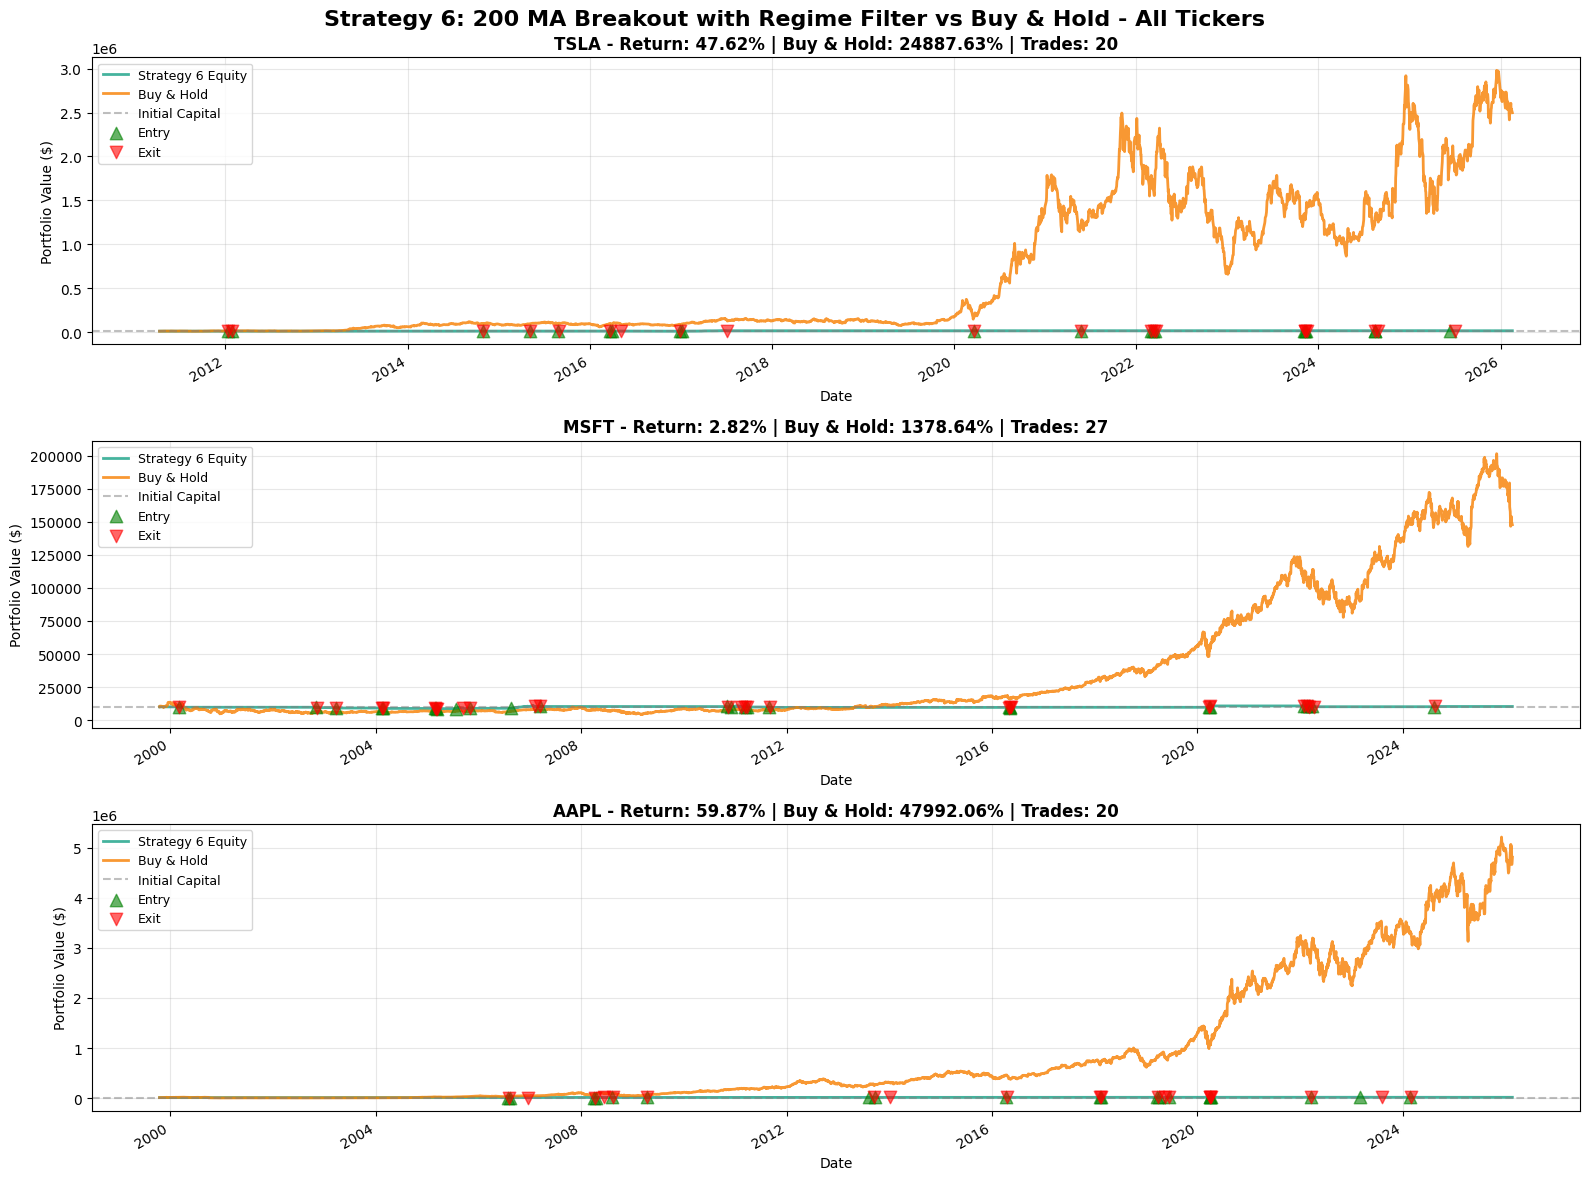


STRATEGY 6 COMPARISON - ALL TICKERS

TSLA:
  Strategy Return: 47.62%
  Buy & Hold Return: 24887.63%
  Difference: -24840.01%

MSFT:
  Strategy Return: 2.82%
  Buy & Hold Return: 1378.64%
  Difference: -1375.82%

AAPL:
  Strategy Return: 59.87%
  Buy & Hold Return: 47992.06%
  Difference: -47932.19%


In [110]:
# Strategy 6: Equity Curve Plots for All Tickers

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Strategy 6: 200 MA Breakout with Regime Filter vs Buy & Hold - All Tickers', fontsize=16, fontweight='bold')

for idx, ticker in enumerate(tickers):
    ax = axes[idx]
    data_ticker = data_s6_dict[ticker]
    results_ticker = results_s6_dict[ticker]
    
    # Calculate Buy & Hold equity curve
    buy_hold_start_price = data_ticker['Adj Close'].iloc[0] if 'Adj Close' in data_ticker.columns else data_ticker['Close'].iloc[0]
    buy_hold_equity = (data_ticker['Adj Close'] / buy_hold_start_price * results_ticker['initial_capital']) if 'Adj Close' in data_ticker.columns else (data_ticker['Close'] / buy_hold_start_price * results_ticker['initial_capital'])
    
    # Plot strategy equity curve
    results_ticker['equity_curve'].plot(ax=ax, label='Strategy 6 Equity', linewidth=2, color='#16A085', alpha=0.8)
    
    # Plot Buy & Hold equity curve
    buy_hold_equity.plot(ax=ax, label='Buy & Hold', linewidth=2, color='#F77F00', alpha=0.8)
    
    # Add reference line for initial capital
    ax.axhline(y=results_ticker['initial_capital'], color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
    
    # Mark entry and exit points if trades exist
    if len(results_ticker['trades']) > 0:
        entry_dates = [t['entry_date'] for t in results_ticker['trades'] if 'entry_date' in t]
        entry_equity = [results_ticker['equity_curve'].loc[date] if date in results_ticker['equity_curve'].index else results_ticker['initial_capital'] for date in entry_dates]
        ax.scatter(entry_dates, entry_equity, color='green', marker='^', s=80, alpha=0.6, label='Entry', zorder=5)
        
        exit_dates = [t['exit_date'] for t in results_ticker['trades'] if 'exit_date' in t]
        exit_equity = [results_ticker['equity_curve'].loc[date] if date in results_ticker['equity_curve'].index else results_ticker['initial_capital'] for date in exit_dates]
        ax.scatter(exit_dates, exit_equity, color='red', marker='v', s=80, alpha=0.6, label='Exit', zorder=5)
    
    ax.set_title(f'{ticker} - Return: {results_ticker["total_return"]:.2f}% | Buy & Hold: {results_ticker["buy_hold_return"]:.2f}% | Trades: {results_ticker["num_trades"]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Portfolio Value ($)', fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison for all tickers
print(f"\n{'='*60}")
print("STRATEGY 6 COMPARISON - ALL TICKERS")
print(f"{'='*60}")
for ticker in tickers:
    r = results_s6_dict[ticker]
    print(f"\n{ticker}:")
    print(f"  Strategy Return: {r['total_return']:.2f}%")
    print(f"  Buy & Hold Return: {r['buy_hold_return']:.2f}%")
    print(f"  Difference: {r['total_return'] - r['buy_hold_return']:.2f}%")
print(f"{'='*60}")


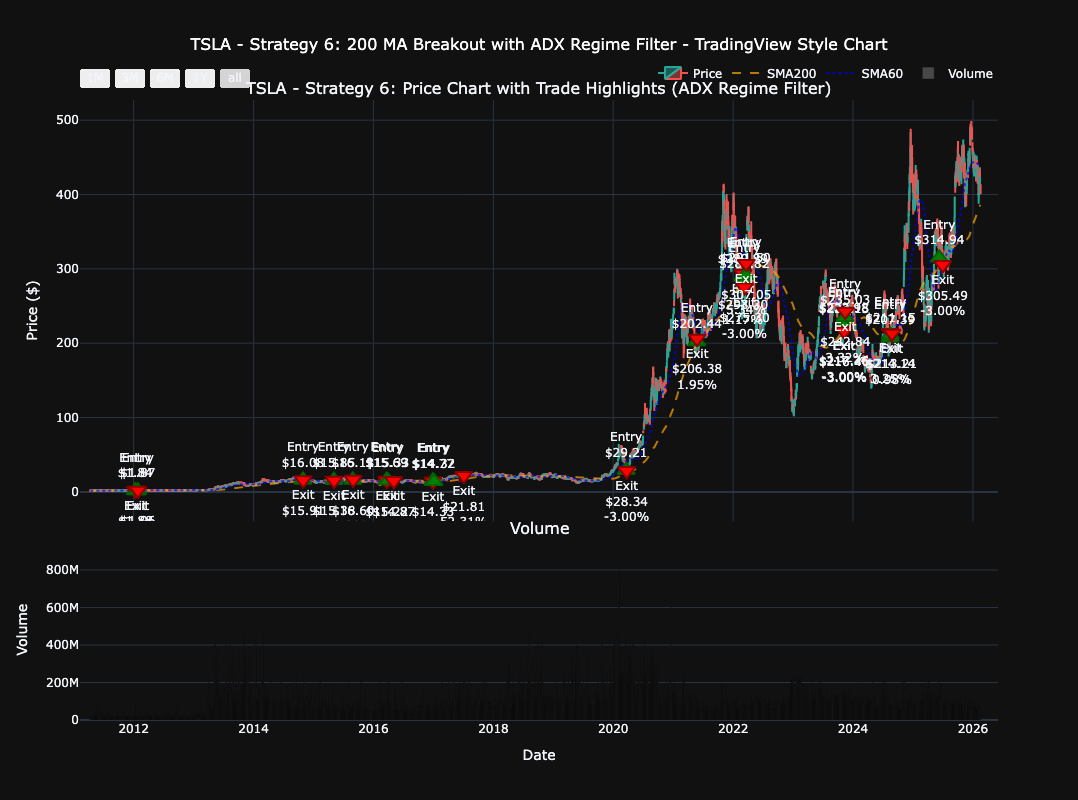


TSLA - INTERACTIVE CHART DISPLAYED
Use zoom tools (top right) to zoom into specific time periods
Hover over entry/exit markers to see trade details
Green triangles = Entry points (ADX > 25 regime filter)
Red triangles = Exit points
Red dotted lines = Stop loss levels (5%)
Orange dashed line = SMA200
Blue dotted line = SMA60
Green/Red dashed lines = Trade connections (green=profit, red=loss)


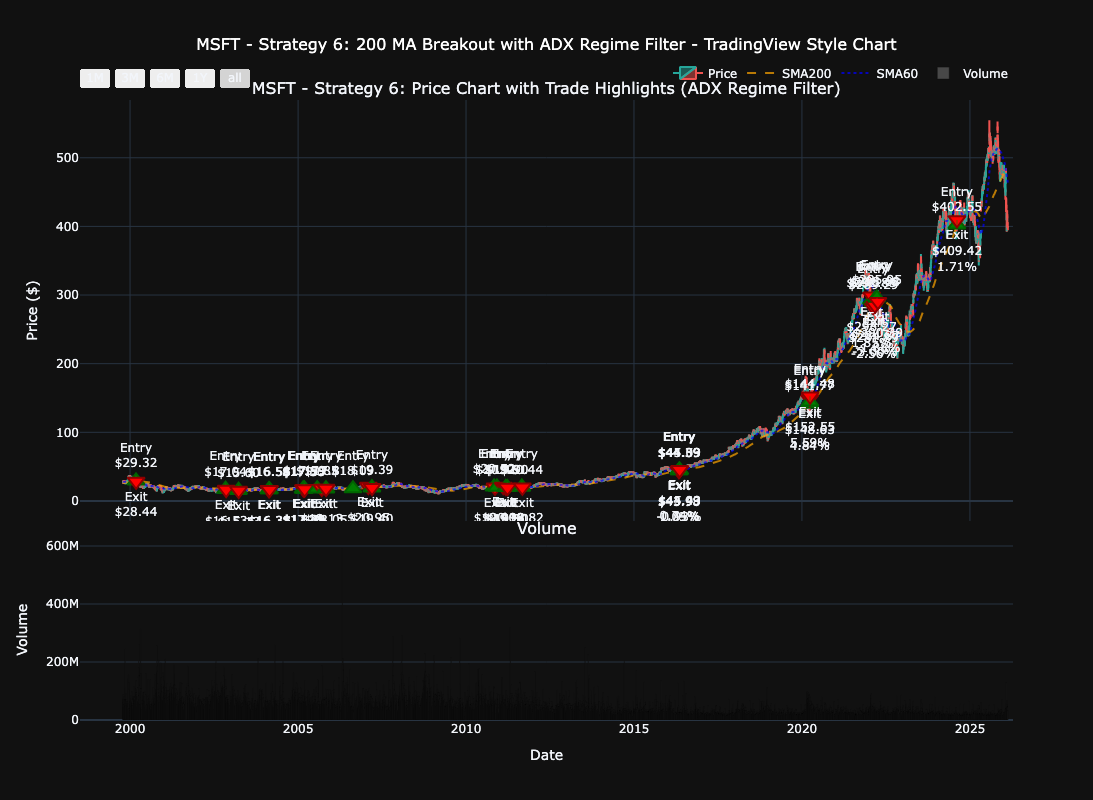


MSFT - INTERACTIVE CHART DISPLAYED
Use zoom tools (top right) to zoom into specific time periods
Hover over entry/exit markers to see trade details
Green triangles = Entry points (ADX > 25 regime filter)
Red triangles = Exit points
Red dotted lines = Stop loss levels (5%)
Orange dashed line = SMA200
Blue dotted line = SMA60
Green/Red dashed lines = Trade connections (green=profit, red=loss)


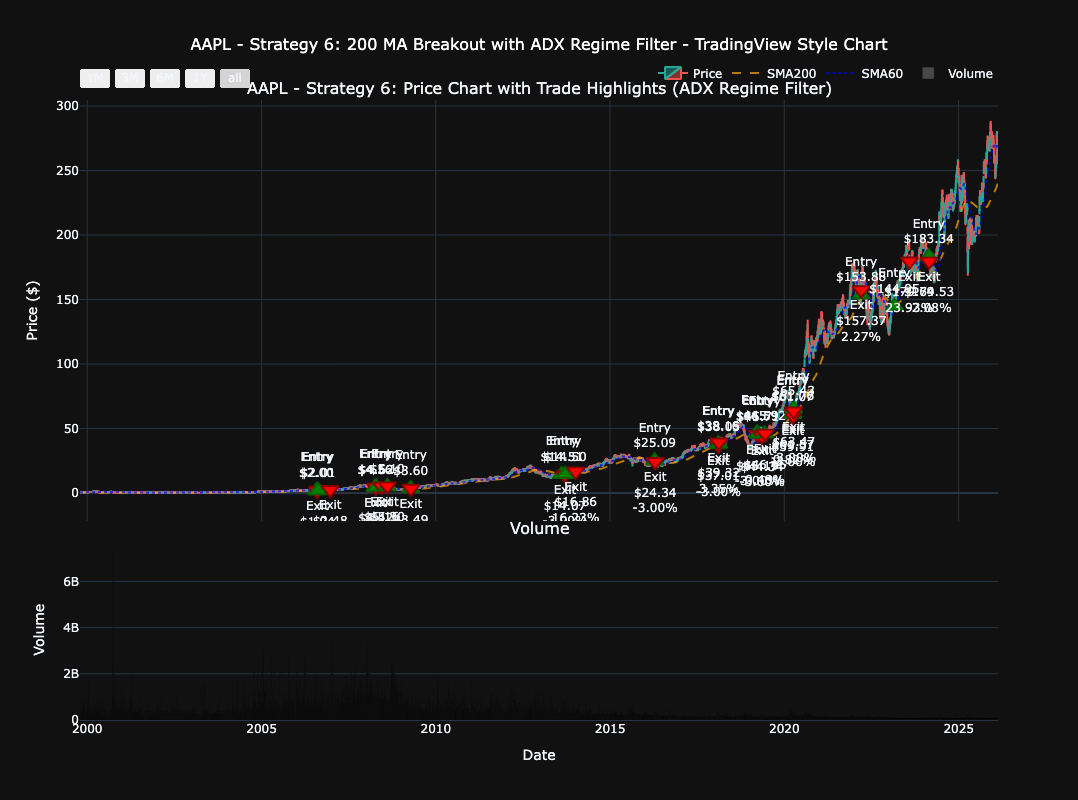


AAPL - INTERACTIVE CHART DISPLAYED
Use zoom tools (top right) to zoom into specific time periods
Hover over entry/exit markers to see trade details
Green triangles = Entry points (ADX > 25 regime filter)
Red triangles = Exit points
Red dotted lines = Stop loss levels (5%)
Orange dashed line = SMA200
Blue dotted line = SMA60
Green/Red dashed lines = Trade connections (green=profit, red=loss)


In [111]:
# Strategy 6: TradingView-Style Charts for All Tickers

for ticker in tickers:
    results_ticker = results_s6_dict[ticker]
    
    if len(results_ticker['trades']) > 0:
        # Prepare data for plotting
        plot_data_s6 = data_s6_dict[ticker].copy()
        
        # Create subplots: price chart on top, volume on bottom
        fig_s6 = make_subplots(
            rows=2, cols=1,
            shared_xaxes=True,
            vertical_spacing=0.03,
            row_heights=[0.7, 0.3],
            subplot_titles=(f'{ticker} - Strategy 6: Price Chart with Trade Highlights (ADX Regime Filter)', 'Volume'),
            specs=[[{"secondary_y": False}], [{"secondary_y": False}]]
        )
        
        # Add candlestick chart
        fig_s6.add_trace(
            go.Candlestick(
                x=plot_data_s6.index,
                open=plot_data_s6['Open'],
                high=plot_data_s6['High'],
                low=plot_data_s6['Low'],
                close=plot_data_s6['Close'],
                name='Price',
                increasing_line_color='#26a69a',
                decreasing_line_color='#ef5350'
            ),
            row=1, col=1
        )
        
        # Add 200-day SMA
        if 'SMA200' in plot_data_s6.columns:
            fig_s6.add_trace(
                go.Scatter(
                    x=plot_data_s6.index,
                    y=plot_data_s6['SMA200'],
                    name='SMA200',
                    line=dict(color='orange', width=2, dash='dash'),
                    opacity=0.7
                ),
                row=1, col=1
            )
        
        # Add 60-day SMA
        if 'SMA60' in plot_data_s6.columns:
            fig_s6.add_trace(
                go.Scatter(
                    x=plot_data_s6.index,
                    y=plot_data_s6['SMA60'],
                    name='SMA60',
                    line=dict(color='blue', width=2, dash='dot'),
                    opacity=0.7
                ),
                row=1, col=1
            )
        
        # Highlight trades: entry points, stop loss levels, and exit points
        for trade in results_ticker['trades']:
            if 'entry_date' in trade and 'exit_date' in trade:
                entry_date = trade['entry_date']
                exit_date = trade['exit_date']
                entry_price = trade['entry_price']
                exit_price = trade.get('exit_price', entry_price)
                stop_loss = trade.get('stop_loss', entry_price * 0.95)
                
                # Get date range for this trade
                trade_mask = (plot_data_s6.index >= entry_date) & (plot_data_s6.index <= exit_date)
                trade_dates = plot_data_s6.index[trade_mask]
                
                if len(trade_dates) > 0:
                    # Draw stop loss line for this trade period
                    stop_loss_line = pd.Series([stop_loss] * len(trade_dates), index=trade_dates)
                    fig_s6.add_trace(
                        go.Scatter(
                            x=stop_loss_line.index,
                            y=stop_loss_line.values,
                            mode='lines',
                            name=f'Stop Loss {entry_date.strftime("%Y-%m-%d")}',
                            line=dict(color='red', width=1, dash='dot'),
                            opacity=0.5,
                            showlegend=False
                        ),
                        row=1, col=1
                    )
                    
                    # Mark entry point
                    fig_s6.add_trace(
                        go.Scatter(
                            x=[entry_date],
                            y=[entry_price],
                            mode='markers+text',
                            name='Entry',
                            marker=dict(
                                symbol='triangle-up',
                                size=15,
                                color='green',
                                line=dict(width=2, color='darkgreen')
                            ),
                            text=[f"Entry<br>${entry_price:.2f}"],
                            textposition="top center",
                            showlegend=False,
                            hovertemplate=f'<b>Entry</b><br>Date: %{{x}}<br>Price: ${entry_price:.2f}<br>Stop: ${stop_loss:.2f}<extra></extra>'
                        ),
                        row=1, col=1
                    )
                    
                    # Mark exit point
                    exit_reason = trade.get('exit_reason', 'unknown')
                    pnl_pct = trade.get('pnl_pct', 0)
                    fig_s6.add_trace(
                        go.Scatter(
                            x=[exit_date],
                            y=[exit_price],
                            mode='markers+text',
                            name='Exit',
                            marker=dict(
                                symbol='triangle-down',
                                size=15,
                                color='red',
                                line=dict(width=2, color='darkred')
                            ),
                            text=[f"Exit<br>${exit_price:.2f}<br>{pnl_pct:.2f}%"],
                            textposition="bottom center",
                            showlegend=False,
                            hovertemplate=f'<b>Exit</b><br>Date: %{{x}}<br>Price: ${exit_price:.2f}<br>Reason: {exit_reason}<br>PnL: {pnl_pct:.2f}%<extra></extra>'
                        ),
                        row=1, col=1
                    )
                    
                    # Draw line connecting entry to exit
                    fig_s6.add_trace(
                        go.Scatter(
                            x=[entry_date, exit_date],
                            y=[entry_price, exit_price],
                            mode='lines',
                            name=f'Trade {entry_date.strftime("%Y-%m-%d")}',
                            line=dict(
                                color='green' if pnl_pct > 0 else 'red',
                                width=2,
                                dash='dash'
                            ),
                            opacity=0.3,
                            showlegend=False,
                            hovertemplate=f'<b>Trade</b><br>PnL: {pnl_pct:.2f}%<br>Hold: {trade.get("hold_days", 0)} days<br>Reason: {exit_reason}<extra></extra>'
                        ),
                        row=1, col=1
                    )
        
        # Add volume bars
        fig_s6.add_trace(
            go.Bar(
                x=plot_data_s6.index,
                y=plot_data_s6['Volume'],
                name='Volume',
                marker_color='rgba(128, 128, 128, 0.5)'
            ),
            row=2, col=1
        )
        
        # Update layout for TradingView-style appearance
        fig_s6.update_layout(
            title=dict(
                text=f'{ticker} - Strategy 6: 200 MA Breakout with ADX Regime Filter - TradingView Style Chart',
                x=0.5,
                font=dict(size=16, color='white')
            ),
            xaxis_rangeslider_visible=False,
            height=800,
            template='plotly_dark',
            hovermode='x unified',
            showlegend=True,
            legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.02,
                xanchor="right",
                x=1
            )
        )
        
        # Update axes
        fig_s6.update_xaxes(title_text="Date", row=2, col=1)
        fig_s6.update_yaxes(title_text="Price ($)", row=1, col=1)
        fig_s6.update_yaxes(title_text="Volume", row=2, col=1)
        
        # Enable zoom and pan with time range selector
        fig_s6.update_layout(
            xaxis=dict(
                rangeselector=dict(
                    buttons=list([
                        dict(count=1, label="1M", step="month", stepmode="backward"),
                        dict(count=3, label="3M", step="month", stepmode="backward"),
                        dict(count=6, label="6M", step="month", stepmode="backward"),
                        dict(count=1, label="1Y", step="year", stepmode="backward"),
                        dict(step="all")
                    ])
                ),
                rangeslider=dict(visible=False),
                type="date"
            )
        )
        
        fig_s6.show()
        
        print(f"\n{'='*60}")
        print(f"{ticker} - INTERACTIVE CHART DISPLAYED")
        print(f"{'='*60}")
        print("Use zoom tools (top right) to zoom into specific time periods")
        print("Hover over entry/exit markers to see trade details")
        print("Green triangles = Entry points (ADX > 25 regime filter)")
        print("Red triangles = Exit points")
        print("Red dotted lines = Stop loss levels (5%)")
        print("Orange dashed line = SMA200")
        print("Blue dotted line = SMA60")
        print("Green/Red dashed lines = Trade connections (green=profit, red=loss)")
        print(f"{'='*60}")
    else:
        print(f"\n{ticker}: No trades to display on chart.")


In [112]:
# Strategy 6: Trade Log Summary for All Tickers

for ticker in tickers:
    results_ticker = results_s6_dict[ticker]
    
    if len(results_ticker['trades']) > 0:
        trades_df_s6 = pd.DataFrame(results_ticker['trades'])
        
        # Format dates for better readability
        if 'entry_date' in trades_df_s6.columns:
            trades_df_s6['entry_date'] = pd.to_datetime(trades_df_s6['entry_date']).dt.strftime('%Y-%m-%d')
        if 'exit_date' in trades_df_s6.columns:
            trades_df_s6['exit_date'] = pd.to_datetime(trades_df_s6['exit_date']).dt.strftime('%Y-%m-%d')
        
        # Round numeric columns
        numeric_cols = ['entry_price', 'exit_price', 'pnl_dollar', 'pnl_pct', 'shares', 'stop_loss']
        for col in numeric_cols:
            if col in trades_df_s6.columns:
                trades_df_s6[col] = trades_df_s6[col].round(2)
        
        print(f"\n{'='*60}")
        print(f"{ticker} - STRATEGY 6 TRADE LOG ({len(trades_df_s6)} trades)")
        print(f"{'='*60}")
        print(trades_df_s6.to_string(index=False))
        
        # Summary by exit reason
        if 'exit_reason' in trades_df_s6.columns:
            print(f"\n{ticker} - TRADES BY EXIT REASON")
            print(f"{'='*60}")
            exit_summary_s6 = trades_df_s6.groupby('exit_reason').agg({
                'pnl_pct': ['count', 'mean', 'sum'],
                'hold_days': 'mean'
            }).round(2)
            exit_summary_s6.columns = ['Count', 'Avg PnL %', 'Total PnL %', 'Avg Hold Days']
            print(exit_summary_s6.to_string())
    else:
        print(f"\n{ticker}: No trades executed.")



TSLA - STRATEGY 6 TRADE LOG (20 trades)
entry_date  entry_price  shares  stop_loss  exit_date  exit_price  pnl_dollar  pnl_pct exit_reason  hold_days  hold_weeks
2012-01-11         1.84 5430.85       1.79 2012-01-12        1.88      228.10     2.28 sma60_touch          1         0.1
2012-01-26         1.87 5465.67       1.82 2012-01-27        1.96      459.12     4.49 sma60_touch          1         0.1
2014-10-29        16.08  664.82      15.59 2014-10-30       15.91     -109.47    -1.02 sma60_touch          1         0.1
2015-05-05        15.85  667.34      15.38 2015-05-06       15.38     -317.33    -3.00   stop_loss          1         0.1
2015-08-28        16.12  636.34      15.64 2015-08-31       16.60      305.44     2.98 sma60_touch          3         0.4
2016-03-21        15.69  673.44      15.22 2016-03-23       15.22     -316.98    -3.00   stop_loss          2         0.3
2016-03-29        15.33  668.72      14.87 2016-05-04       14.87     -307.47    -3.00   stop_loss       

**Strategy 6 Summary:**

Adds ADX > 25 regime filter to skip choppy periods around SMA200. Loosens stop to 5%, exits on SMA60 touch for longer runs in trends.

**Key Features:**
- **ADX Regime Filter**: Only enters when ADX(14) > 25 on breakout day, filtering out choppy/non-trending markets
- **Next Day Entry**: When breakout detected with strong trend (ADX > 25), enter at next day's opening price if Open > SMA200
- **Looser Stop**: 5% stop loss (vs 2% in Strategy 5) for breathing room in volatile markets
- **Dynamic Exit**: Exits on SMA60 touch instead of fixed time, allowing longer winners in strong trends
- **Position Sizing**: Full available capital per trade (100% position size)
- **No Pattern Exits**: Removed all bearish candlestick pattern-based exits

**Tunable Parameters:**
- `stop_loss_pct`: Stop loss percentage (default: 5%)
- `adx_threshold`: ADX threshold for regime filter (default: 25)
- SMA periods: Can adjust SMA200 and SMA60 window sizes
- ADX period: Can adjust ADX timeperiod (default: 14)

**Why This Should Improve:**
- Fewer false entries: ADX filter reduces whipsaws in choppy markets around SMA200
- Better trend alignment: Only trades in strong trending markets
- Longer winners: SMA60 exit allows positions to run longer in trends
- Reduced volatility stops: 5% stop gives more room for normal market fluctuations


**Strategy 5 Summary:**

Entry on next day's open after breakout (if Open > SMA200). Exit on 2% SL or >8 weeks. No bearish patterns, no SMA60 touch exit.

**Key Features:**
- **Next Day Entry**: When breakout detected (Close > SMA200), enter at next day's opening price if Open > SMA200
- **Simple Exit Rules**: Only stop loss (2%) and time exit (>8 weeks)
- **No Pattern Exits**: Removed all bearish candlestick pattern-based exits
- **Position Sizing**: Full available capital per trade (100% position size) with 2% fixed stop loss

**Tunable Parameters:**
- `stop_loss_pct`: Stop loss percentage (default: 2%)
- `max_weeks_hold`: Maximum holding period in weeks (default: 8 weeks)
- Position sizing: Uses full available capital per trade (100% position size)
- SMA periods: Can adjust SMA200 and SMA60 window sizes
